In [ ]:
import pandas as pd
import numpy as np

import sys
import warnings
import itertools
warnings.filterwarnings("ignore")

In [ ]:
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path="/content/drive/MyDrive/PDSBA/CPN2/3Modelling_output.xlsx"
df=pd.read_excel(path)

Mounted at /content/drive


In [ ]:
df.head()

,default,total_purchases_12_24m,days_in_debt_collection_12_24m,days_in_reminder_12_24m,days_in_termination_12_24m,age,avg_payment_span_0_12m,merchant_category,merchant_group,has_paid,...,num_arch_rem_0_12m,max_archived_status_0_6_months,max_archived_status_0_12_months,max_archived_status_0_24_months,recovery_debt,sum_capital_paid_acct_0_12m,sum_capital_paid_acct_12_24m,sum_paid_inv_0_12m,time_hours,log_sum_paid_inv_0_12m
0,0.0,357678.0,0.000000,0.00000,0.000000,20.0,12.692308,Dietary supplements,Health & Beauty,1.0,...,0.0,14.0,14.0,14.0,0.0,0.0,0.0,178839.0,9.653333,12.094241
1,0.0,98028.0,0.000000,0.00000,0.000000,50.0,25.833333,Books & Magazines,Entertainment,1.0,...,3.0,19.0,19.0,19.0,0.0,0.0,0.0,49014.0,13.181389,10.799861
2,0.0,249678.0,0.000000,0.00000,0.000000,22.0,20.000000,Diversified entertainment,Entertainment,1.0,...,3.0,11.0,11.0,11.0,0.0,0.0,0.0,124839.0,11.561944,11.734780
3,0.0,649352.0,0.357325,5.17885,0.421177,36.0,4.687500,Diversified entertainment,Entertainment,1.0,...,0.0,31.0,31.0,31.0,0.0,0.0,0.0,324676.0,15.751111,12.690583
4,0.0,14200.0,0.000000,0.00000,0.000000,25.0,13.000000,Electronic equipment & Related accessories,Electronics,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,7100.0,12.698611,8.867850


In [ ]:
df.shape

(99979, 29)

In [ ]:
df.isnull().sum()

default                            0
total_purchases_12_24m             0
days_in_debt_collection_12_24m     0
days_in_reminder_12_24m            0
days_in_termination_12_24m         0
age                                0
avg_payment_span_0_12m             0
merchant_category                  0
merchant_group                     0
has_paid                           0
max_paid_inv_0_12m                 0
max_paid_inv_0_24m                 0
name_in_email                      0
active_div_by_paid_ratio_0_12m     0
num_active_invoices                0
num_arch_dc_0_12m                  0
num_arch_dc_12_24m                 0
num_arch_ok_0_12m                  0
num_arch_ok_12_24m                 0
num_arch_rem_0_12m                 0
max_archived_status_0_6_months     0
max_archived_status_0_12_months    0
max_archived_status_0_24_months    0
recovery_debt                      0
sum_capital_paid_acct_0_12m        0
sum_capital_paid_acct_12_24m       0
sum_paid_inv_0_12m                 0
t

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99979 entries, 0 to 99978
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   default                          99979 non-null  float64
 1   total_purchases_12_24m           99979 non-null  float64
 2   days_in_debt_collection_12_24m   99979 non-null  float64
 3   days_in_reminder_12_24m          99979 non-null  float64
 4   days_in_termination_12_24m       99979 non-null  float64
 5   age                              99979 non-null  float64
 6   avg_payment_span_0_12m           99979 non-null  float64
 7   merchant_category                99979 non-null  object 
 8   merchant_group                   99979 non-null  object 
 9   has_paid                         99979 non-null  float64
 10  max_paid_inv_0_12m               99979 non-null  float64
 11  max_paid_inv_0_24m               99979 non-null  float64
 12  name_in_email     

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
default,99979.0,1.432588e-02,0.112730,0.0,0.000000,0.000000,0.000000,1.000000e+00
total_purchases_12_24m,99979.0,8.207181e+04,178445.628838,0.0,9740.000000,43948.000000,82071.812194,5.925740e+06
days_in_debt_collection_12_24m,99979.0,3.573252e-01,37.827081,0.0,0.000000,0.000000,0.000000,1.183600e+04
days_in_reminder_12_24m,99979.0,5.178850e+00,43.137745,0.0,0.000000,0.000000,0.000000,1.183600e+04
days_in_termination_12_24m,99979.0,4.211774e-01,37.532669,0.0,0.000000,0.000000,0.000000,1.183600e+04
age,99979.0,3.601592e+01,13.001610,0.0,25.000000,34.000000,45.000000,1.000000e+02
avg_payment_span_0_12m,99979.0,1.828429e+01,76.144468,0.0,12.200000,18.100000,18.597297,2.383600e+04
has_paid,99979.0,8.657455e-01,0.321561,0.0,1.000000,1.000000,1.000000,1.000000e+00
max_paid_inv_0_12m,99979.0,9.362712e+03,12895.750215,0.0,2990.000000,7082.000000,10570.000000,2.790000e+05
max_paid_inv_0_24m,99979.0,1.141961e+04,14555.100537,0.0,4249.500000,8950.000000,12785.000000,5.385000e+05


In [ ]:
print("\nInformation about the index of the dataset:")
print(df.index)

print("\nColumn names of the dataset:")
print(df.columns)


Information about the index of the dataset:
RangeIndex(start=0, stop=99979, step=1)

Column names of the dataset:
Index(['default', 'total_purchases_12_24m', 'days_in_debt_collection_12_24m',
       'days_in_reminder_12_24m', 'days_in_termination_12_24m', 'age',
       'avg_payment_span_0_12m', 'merchant_category', 'merchant_group',
       'has_paid', 'max_paid_inv_0_12m', 'max_paid_inv_0_24m', 'name_in_email',
       'active_div_by_paid_ratio_0_12m', 'num_active_invoices',
       'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m',
       'num_arch_ok_12_24m', 'num_arch_rem_0_12m',
       'max_archived_status_0_6_months', 'max_archived_status_0_12_months',
       'max_archived_status_0_24_months', 'recovery_debt',
       'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
       'sum_paid_inv_0_12m', 'time_hours', 'log_sum_paid_inv_0_12m'],
      dtype='object')


In [ ]:
df.shape

(99979, 29)

In [ ]:
import pandas as pd
from scipy import stats
df_copy = df.copy()
numeric_cols = df_copy.select_dtypes(include='number').columns
df_numeric = df_copy[numeric_cols]

df_numeric = df_numeric.dropna()

z_scores = stats.zscore(df_numeric)

threshold = 3

outliers = (abs(z_scores) > threshold)

num_outliers = outliers.sum(axis=0)

print("Number of outliers in each column:")
print(num_outliers)

Number of outliers in each column:
default                            1289
total_purchases_12_24m             1228
days_in_debt_collection_12_24m       52
days_in_reminder_12_24m             662
days_in_termination_12_24m            1
age                                 433
avg_payment_span_0_12m                2
has_paid                              0
max_paid_inv_0_12m                 1687
max_paid_inv_0_24m                 1687
active_div_by_paid_ratio_0_12m        0
num_active_invoices                1287
num_arch_dc_0_12m                   960
num_arch_dc_12_24m                  961
num_arch_ok_0_12m                  2051
num_arch_ok_12_24m                 1809
num_arch_rem_0_12m                 1508
max_archived_status_0_6_months     2037
max_archived_status_0_12_months    2037
max_archived_status_0_24_months    2037
recovery_debt                       192
sum_capital_paid_acct_0_12m        2151
sum_capital_paid_acct_12_24m       2166
sum_paid_inv_0_12m                 1228
time_

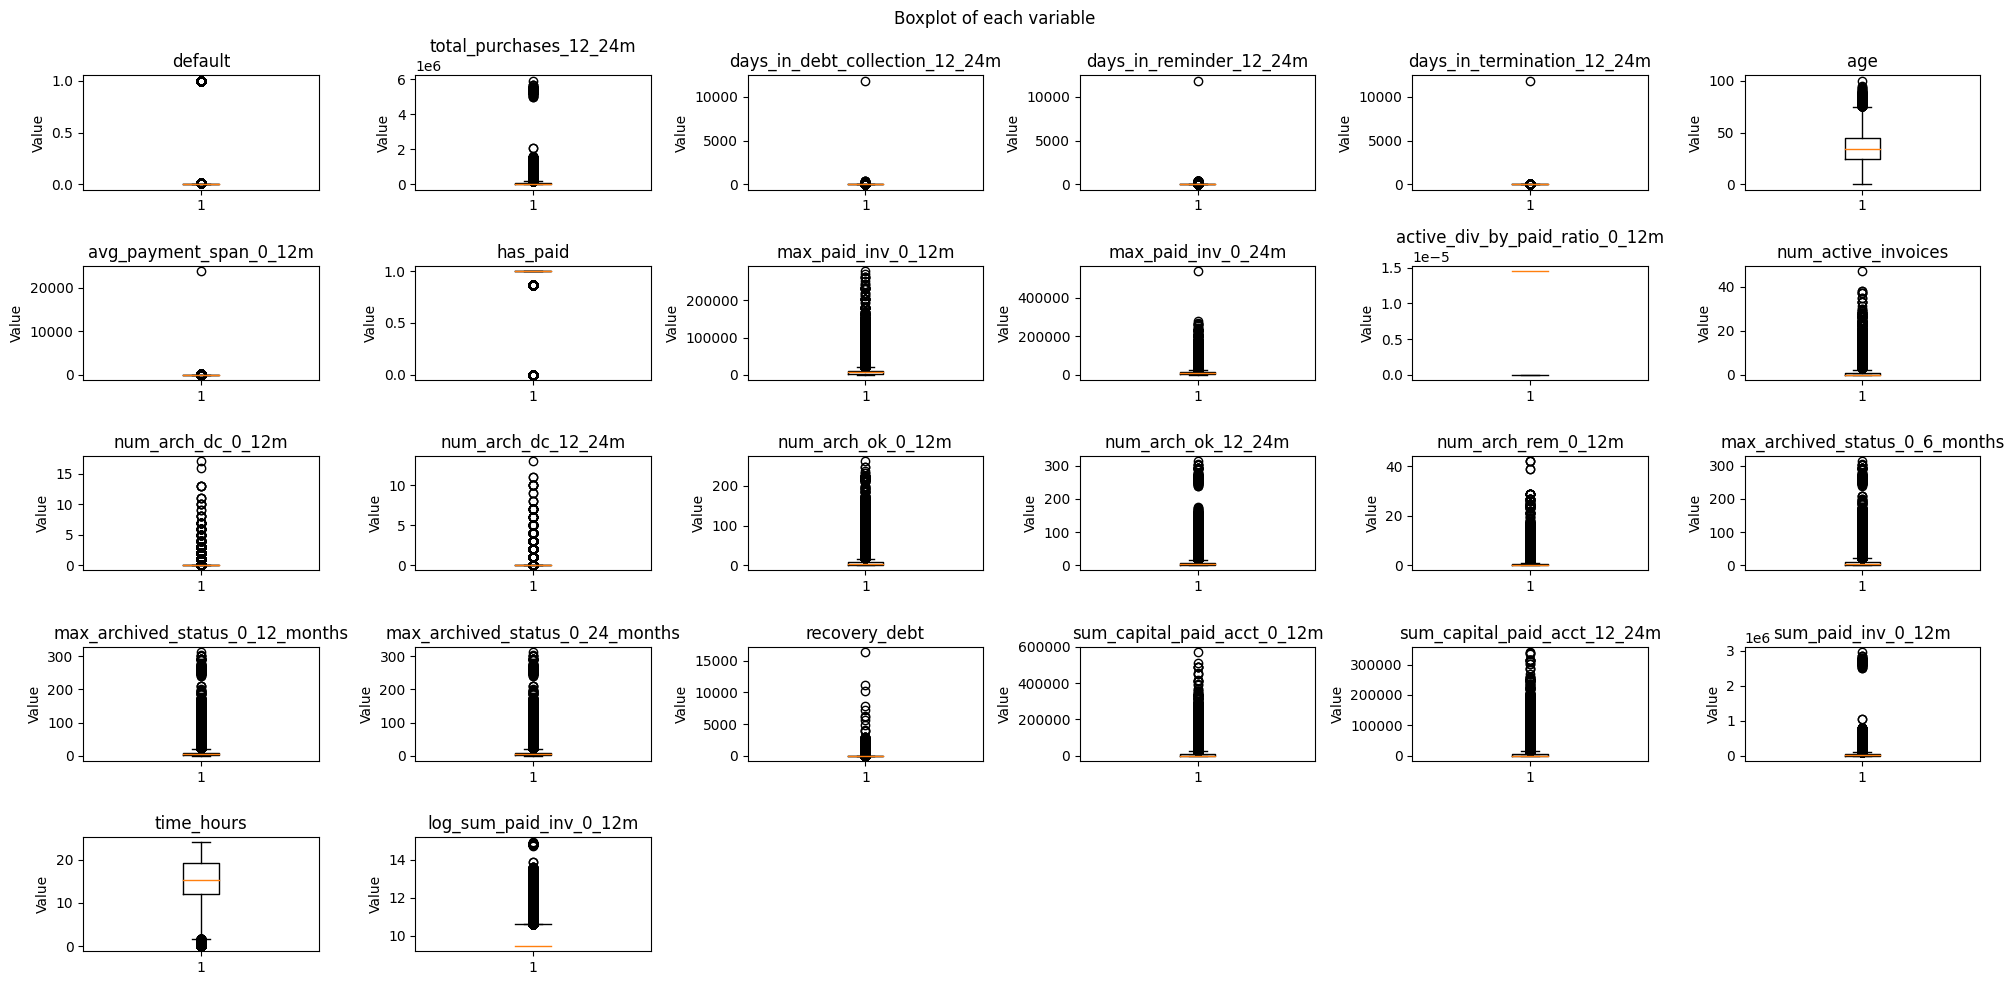

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(20, 10))
for i, column in enumerate(numeric_df.columns):
    plt.subplot(5, 6, i + 1)
    plt.boxplot(numeric_df[column])
    plt.title(column)
    plt.ylabel('Value')

plt.suptitle('Boxplot of each variable')
plt.tight_layout()
plt.show()

In [ ]:
tolerance = 0.0001

df = df.copy()
df.loc[df['default'].between(0.014326 - tolerance, 0.014326 + tolerance), 'default'] = 0

default_distribution_updated = df['default'].value_counts()
print("Updated Class Distribution:")
print(default_distribution_updated)

Updated Class Distribution:
default
0.0    98690
1.0     1289
Name: count, dtype: int64


In [ ]:
df.head()

,default,total_purchases_12_24m,days_in_debt_collection_12_24m,days_in_reminder_12_24m,days_in_termination_12_24m,age,avg_payment_span_0_12m,merchant_category,merchant_group,has_paid,...,num_arch_rem_0_12m,max_archived_status_0_6_months,max_archived_status_0_12_months,max_archived_status_0_24_months,recovery_debt,sum_capital_paid_acct_0_12m,sum_capital_paid_acct_12_24m,sum_paid_inv_0_12m,time_hours,log_sum_paid_inv_0_12m
0,0.0,357678.0,0.000000,0.00000,0.000000,20.0,12.692308,Dietary supplements,Health & Beauty,1.0,...,0.0,14.0,14.0,14.0,0.0,0.0,0.0,178839.0,9.653333,12.094241
1,0.0,98028.0,0.000000,0.00000,0.000000,50.0,25.833333,Books & Magazines,Entertainment,1.0,...,3.0,19.0,19.0,19.0,0.0,0.0,0.0,49014.0,13.181389,10.799861
2,0.0,249678.0,0.000000,0.00000,0.000000,22.0,20.000000,Diversified entertainment,Entertainment,1.0,...,3.0,11.0,11.0,11.0,0.0,0.0,0.0,124839.0,11.561944,11.734780
3,0.0,649352.0,0.357325,5.17885,0.421177,36.0,4.687500,Diversified entertainment,Entertainment,1.0,...,0.0,31.0,31.0,31.0,0.0,0.0,0.0,324676.0,15.751111,12.690583
4,0.0,14200.0,0.000000,0.00000,0.000000,25.0,13.000000,Electronic equipment & Related accessories,Electronics,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,7100.0,12.698611,8.867850


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(include='object').columns
default_column = df['default']

df_numeric = df[numeric_columns]

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_imputed = df_numeric.copy()

for column in df_numeric.columns:
    outliers_lower = df_imputed[column] < lower_bound[column]
    outliers_upper = df_imputed[column] > upper_bound[column]
    median = df[column].median()
    df_imputed.loc[outliers_lower, column] = median
    df_imputed.loc[outliers_upper, column] = median

for column in categorical_columns:
    df_imputed[column] = df[column]

df_imputed['default'] = default_column

# Aligning indices
df_imputed, lower_bound_aligned = df_imputed.align(lower_bound, axis=1, copy=False)
df_imputed, upper_bound_aligned = df_imputed.align(upper_bound, axis=1, copy=False)

# Computing the count of outliers
outliers_count_updated = ((df_imputed < lower_bound_aligned) | (df_imputed > upper_bound_aligned)).sum()
print("Updated count of outliers after treatment:\n", outliers_count_updated)

df2 = df_imputed

print("\nShape of df2:", df2.shape)


Updated count of outliers after treatment:
 active_div_by_paid_ratio_0_12m        0
age                                   0
avg_payment_span_0_12m                0
days_in_debt_collection_12_24m        0
days_in_reminder_12_24m               0
days_in_termination_12_24m            0
default                            1289
has_paid                              0
log_sum_paid_inv_0_12m                0
max_archived_status_0_12_months       0
max_archived_status_0_24_months       0
max_archived_status_0_6_months        0
max_paid_inv_0_12m                    0
max_paid_inv_0_24m                    0
merchant_category                     0
merchant_group                        0
name_in_email                         0
num_active_invoices                   0
num_arch_dc_0_12m                     0
num_arch_dc_12_24m                    0
num_arch_ok_0_12m                     0
num_arch_ok_12_24m                    0
num_arch_rem_0_12m                    0
recovery_debt                       

In [ ]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
active_div_by_paid_ratio_0_12m,99979.0,inf,NaN,0.000000,0.000000,0.000015,NaN,inf
age,99979.0,3.581646e+01,12.671122,0.000000,25.000000,34.000000,45.000000,7.500000e+01
avg_payment_span_0_12m,99979.0,1.578822e+01,4.879043,2.615385,12.568323,18.100000,18.284287,2.818750e+01
days_in_debt_collection_12_24m,99979.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
days_in_reminder_12_24m,99979.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
days_in_termination_12_24m,99979.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
default,99979.0,1.289271e-02,0.112812,0.000000,0.000000,0.000000,0.000000,1.000000e+00
has_paid,99979.0,1.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
log_sum_paid_inv_0_12m,99979.0,-inf,NaN,-inf,NaN,9.464983,10.606412,1.490167e+01
max_archived_status_0_12_months,99979.0,5.236764e+00,4.662149,0.000000,1.000000,5.000000,9.000000,2.100000e+01


In [ ]:
df2.shape

(99979, 29)

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("Count of values in column '{}':".format(column))
    print(df[column].value_counts())
    print()

Count of values in column 'merchant_category':
merchant_category
Diversified entertainment                                  38616
Youthful Shoes & Clothing                                  11755
Books & Magazines                                           9363
General Shoes & Clothing                                    4597
Concept stores & Miscellaneous                              4406
Sports gear & Outdoor                                       3712
Dietary supplements                                         3101
Diversified children products                               2994
Diversified electronics                                     1844
Prints & Photos                                             1675
Children Clothes & Nurturing products                       1500
Pet supplies                                                1315
Electronic equipment & Related accessories                  1037
Jewelry & Watches                                            911
Hobby articles           

In [ ]:
df2['default'].value_counts()

default
0.0    98690
1.0     1289
Name: count, dtype: int64

In [ ]:
df2.head()

,active_div_by_paid_ratio_0_12m,age,avg_payment_span_0_12m,days_in_debt_collection_12_24m,days_in_reminder_12_24m,days_in_termination_12_24m,default,has_paid,log_sum_paid_inv_0_12m,max_archived_status_0_12_months,...,num_arch_dc_12_24m,num_arch_ok_0_12m,num_arch_ok_12_24m,num_arch_rem_0_12m,recovery_debt,sum_capital_paid_acct_0_12m,sum_capital_paid_acct_12_24m,sum_paid_inv_0_12m,time_hours,total_purchases_12_24m
0,0.000011,20.0,12.692308,0.0,0.0,0.0,0.0,1.0,12.094241,14.0,...,0.0,13.0,14.0,0.0,0.0,0.0,0.0,21974.0,9.653333,43948.0
1,0.000000,50.0,25.833333,0.0,0.0,0.0,0.0,1.0,10.799861,19.0,...,0.0,9.0,3.0,0.0,0.0,0.0,0.0,49014.0,13.181389,98028.0
2,0.000008,22.0,20.000000,0.0,0.0,0.0,0.0,1.0,11.734780,11.0,...,0.0,11.0,0.0,0.0,0.0,0.0,0.0,21974.0,11.561944,43948.0
3,0.000003,36.0,4.687500,0.0,0.0,0.0,0.0,1.0,12.690583,5.0,...,0.0,3.0,3.0,0.0,0.0,0.0,0.0,21974.0,15.751111,43948.0
4,0.000000,25.0,13.000000,0.0,0.0,0.0,0.0,1.0,8.867850,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7100.0,12.698611,14200.0


In [ ]:
import numpy as np

df2.replace([np.inf, -np.inf], np.nan, inplace=True)

df2.dropna(inplace=True)

df2.reset_index(drop=True, inplace=True)


In [ ]:
df2.shape

(71096, 29)

In [ ]:
df2['default'].value_counts()

default
0.0    70395
1.0      701
Name: count, dtype: int64

In [ ]:
print(df2.columns)

target_variable = df2['default']

Index(['active_div_by_paid_ratio_0_12m', 'age', 'avg_payment_span_0_12m',
       'days_in_debt_collection_12_24m', 'days_in_reminder_12_24m',
       'days_in_termination_12_24m', 'default', 'has_paid',
       'log_sum_paid_inv_0_12m', 'max_archived_status_0_12_months',
       'max_archived_status_0_24_months', 'max_archived_status_0_6_months',
       'max_paid_inv_0_12m', 'max_paid_inv_0_24m', 'merchant_category',
       'merchant_group', 'name_in_email', 'num_active_invoices',
       'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m',
       'num_arch_ok_12_24m', 'num_arch_rem_0_12m', 'recovery_debt',
       'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
       'sum_paid_inv_0_12m', 'time_hours', 'total_purchases_12_24m'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

numeric_features = ['total_purchases_12_24m', 'days_in_debt_collection_12_24m',
                    'days_in_reminder_12_24m', 'days_in_termination_12_24m', 'age',
                    'avg_payment_span_0_12m', 'has_paid', 'max_paid_inv_0_12m',
                    'max_paid_inv_0_24m', 'active_div_by_paid_ratio_0_12m',
                    'num_active_invoices', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m',
                    'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m',
                    'max_archived_status_0_6_months', 'max_archived_status_0_12_months',
                    'max_archived_status_0_24_months', 'recovery_debt',
                    'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
                    'sum_paid_inv_0_12m', 'time_hours', 'log_sum_paid_inv_0_12m']

categorical_features = ['merchant_category', 'merchant_group', 'name_in_email']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_processed = preprocessor.fit_transform(df2)
y = df2['default']

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)

In [ ]:
print("Training data shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing data shape (X_test, y_test):", X_test.shape, y_test.shape)

Training data shape (X_train, y_train): (49767, 92) (49767,)
Testing data shape (X_test, y_test): (21329, 92) (21329,)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training AdaBoost
Training Gradient Boosting
Training Bagging
Training LightGBM
[LightGBM] [Info] Number of positive: 485, number of negative: 49282
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2843
[LightGBM] [Info] Number of data points in the train set: 49767, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.009745 -> initscore=-4.621165
[LightGBM] [Info] Start training from score -4.621165
Training XGBoost
Training Linear Discriminant Analysis

Training Results Summary:
Model: Logistic Regression
Accuracy: 0.9899198274649538
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0      

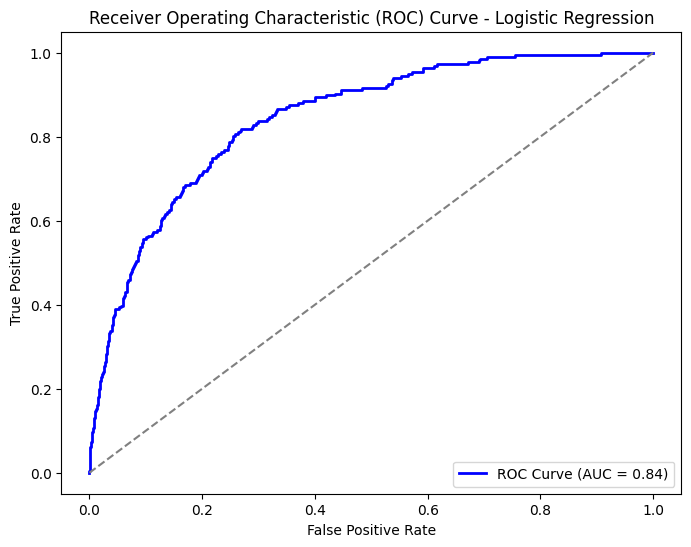

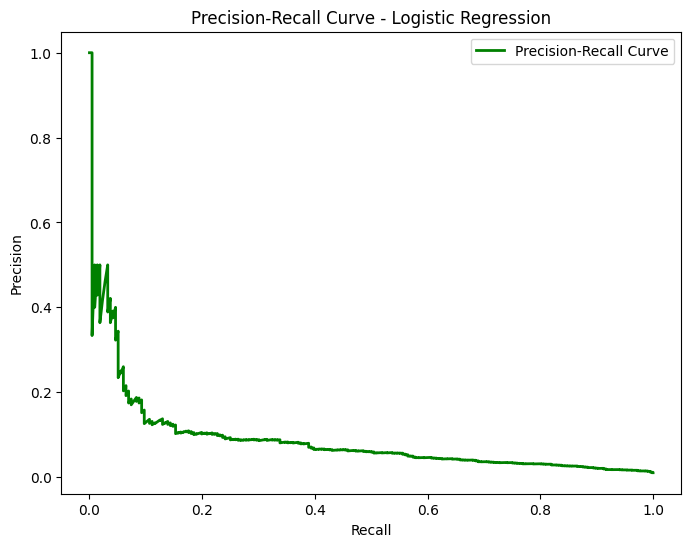

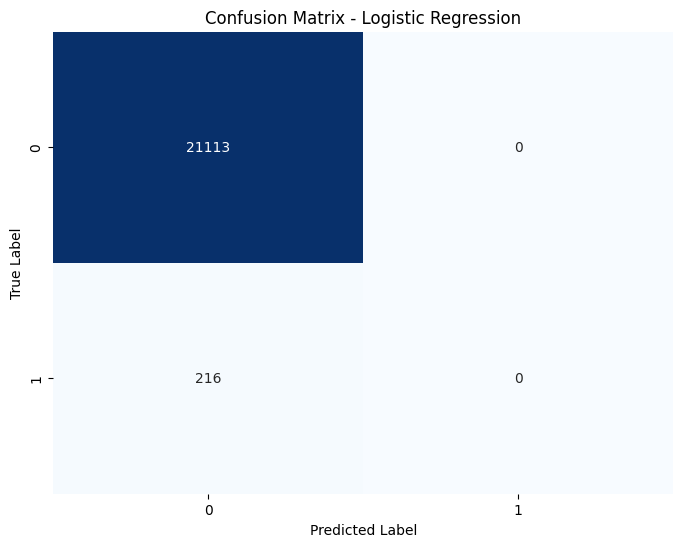

Model: Decision Tree
Accuracy: 0.9814806132495664
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     21113
         1.0       0.14      0.16      0.15       216

    accuracy                           0.98     21329
   macro avg       0.57      0.58      0.57     21329
weighted avg       0.98      0.98      0.98     21329





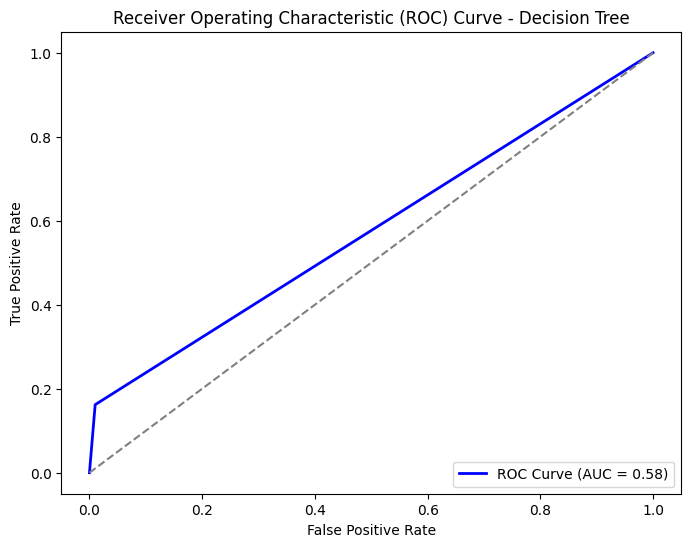

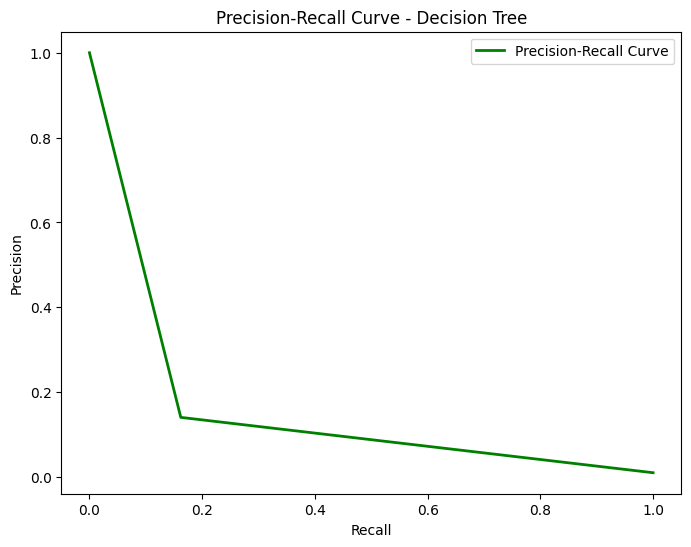

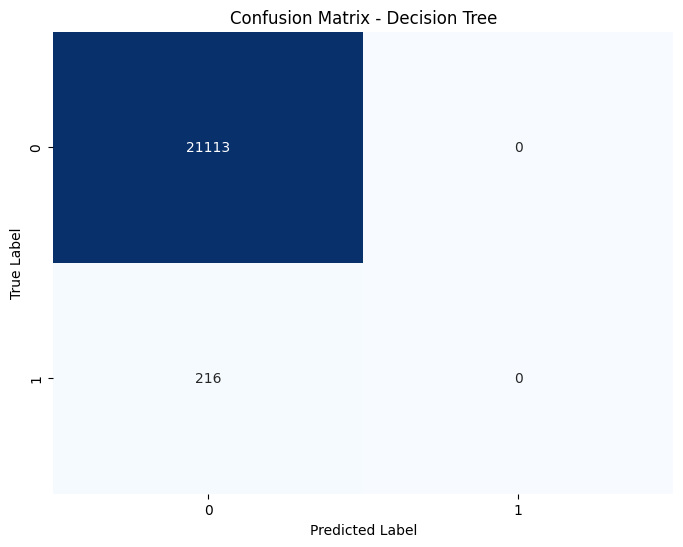

Model: Random Forest
Accuracy: 0.9904355572225608
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.93      0.06      0.11       216

    accuracy                           0.99     21329
   macro avg       0.96      0.53      0.55     21329
weighted avg       0.99      0.99      0.99     21329





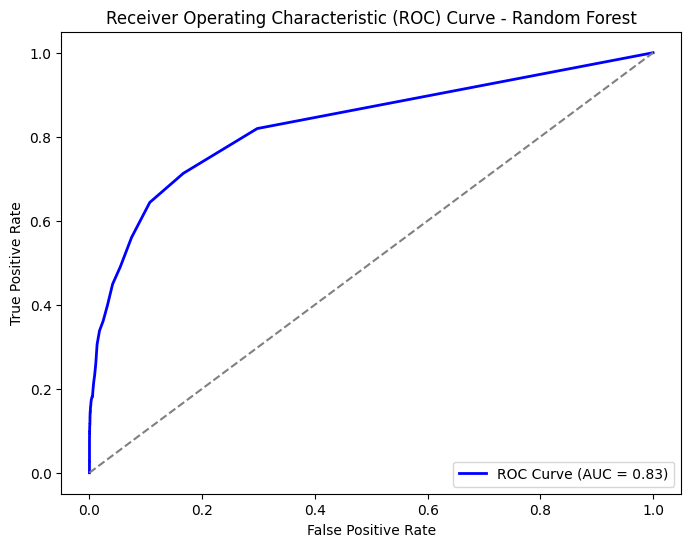

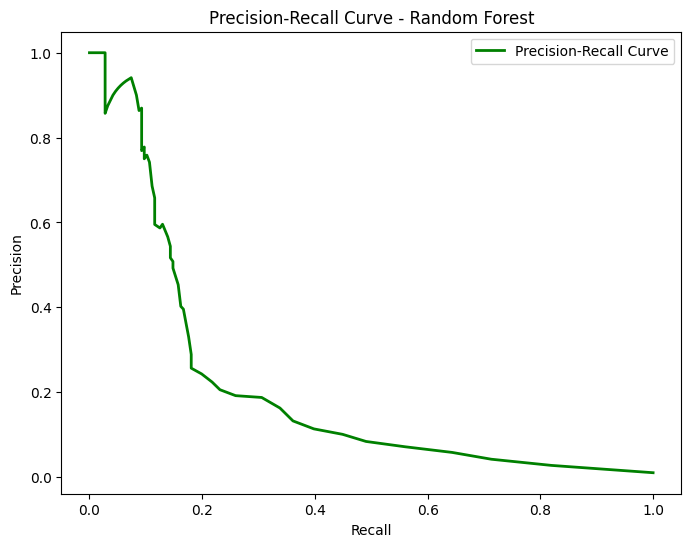

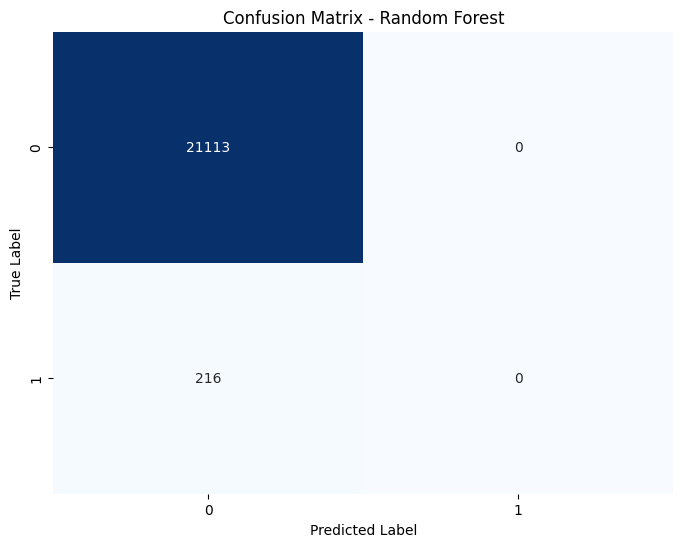

Model: AdaBoost
Accuracy: 0.9895447512776032
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.33      0.03      0.06       216

    accuracy                           0.99     21329
   macro avg       0.66      0.52      0.53     21329
weighted avg       0.98      0.99      0.99     21329





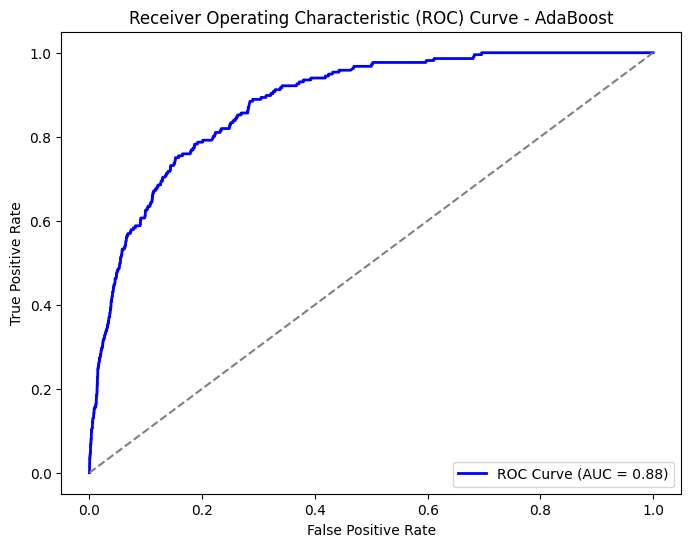

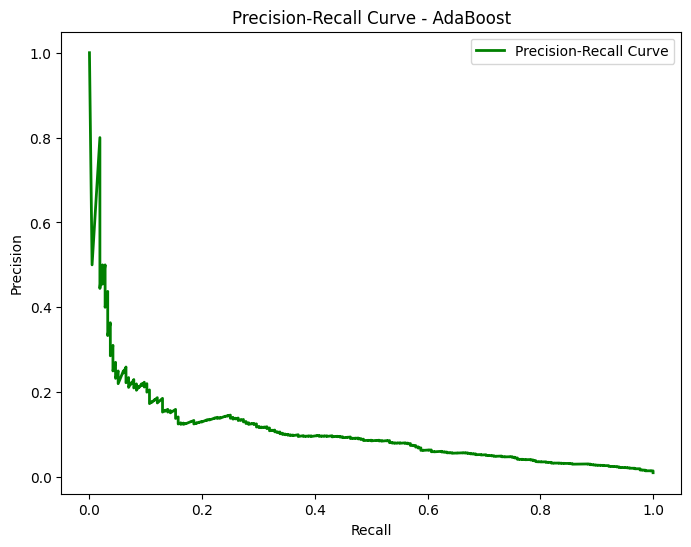

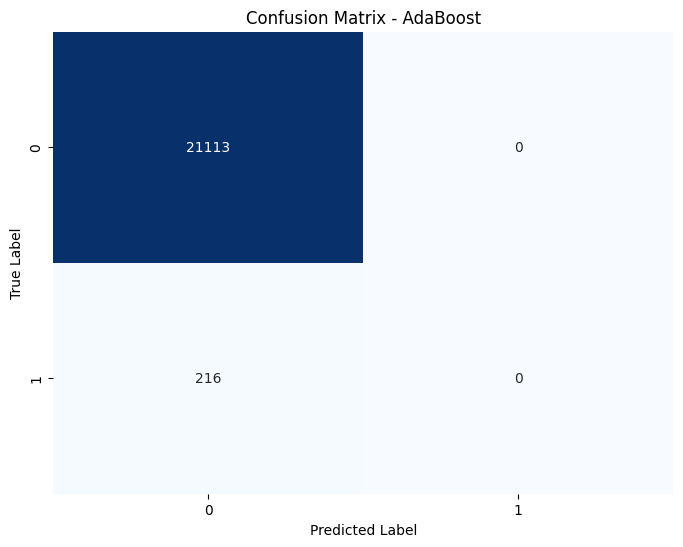

Model: Gradient Boosting
Accuracy: 0.9890759060434151
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.26      0.04      0.07       216

    accuracy                           0.99     21329
   macro avg       0.62      0.52      0.53     21329
weighted avg       0.98      0.99      0.99     21329





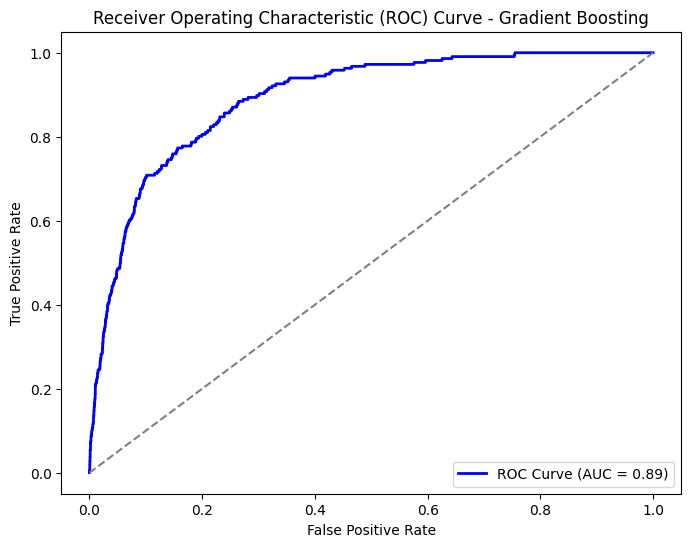

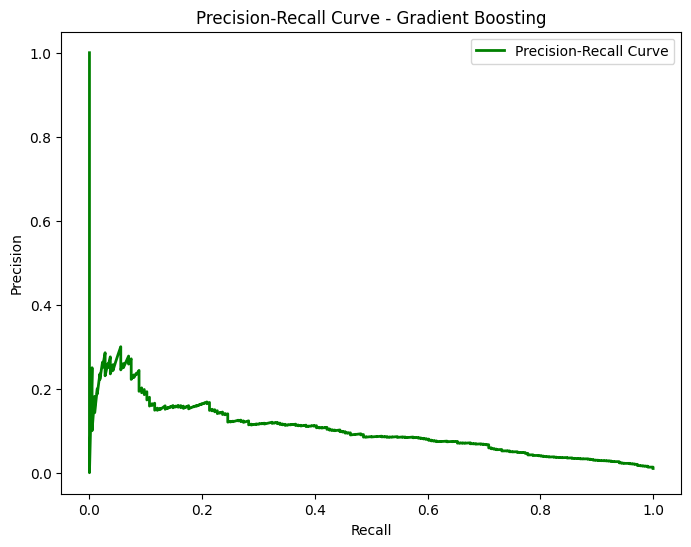

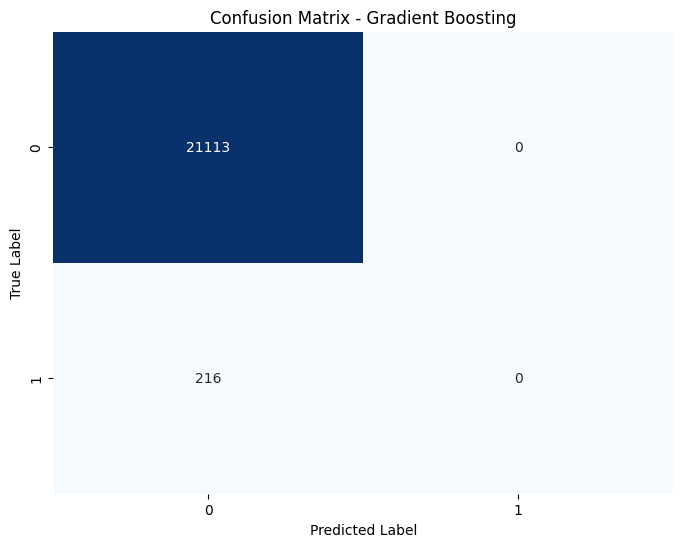

Model: Bagging
Accuracy: 0.9894978667541845
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.35      0.04      0.07       216

    accuracy                           0.99     21329
   macro avg       0.67      0.52      0.53     21329
weighted avg       0.98      0.99      0.99     21329





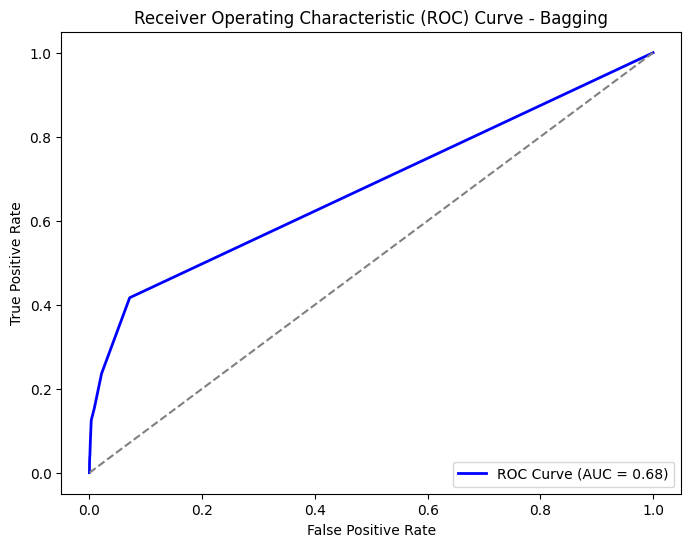

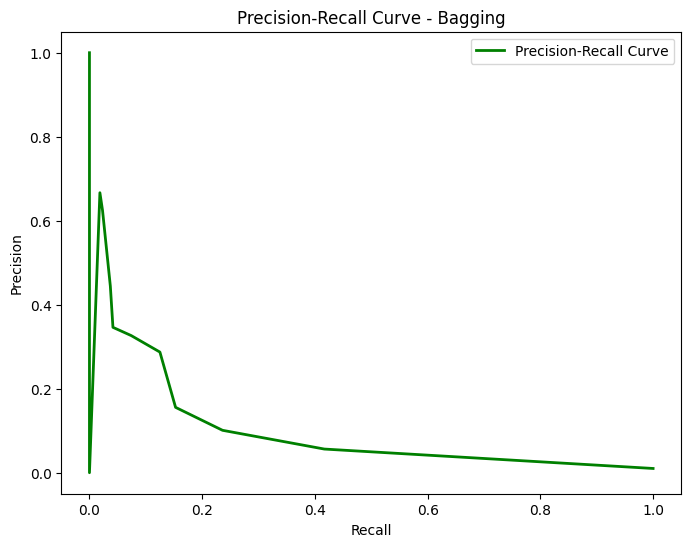

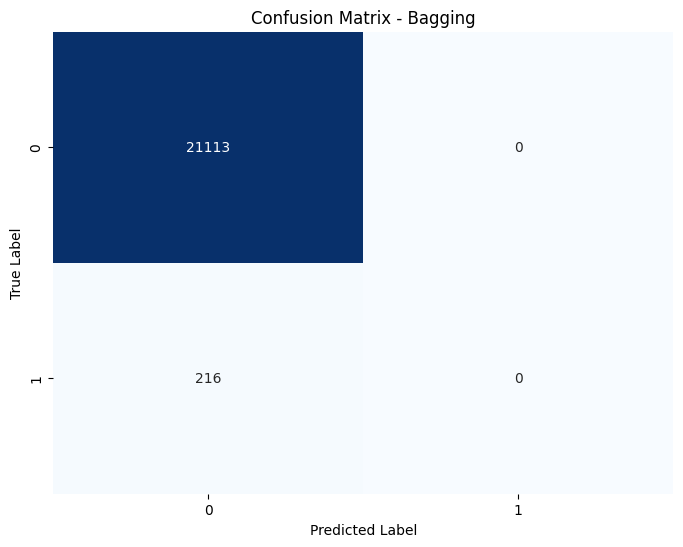

Model: LightGBM
Accuracy: 0.9890759060434151
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.33      0.07      0.12       216

    accuracy                           0.99     21329
   macro avg       0.66      0.54      0.56     21329
weighted avg       0.98      0.99      0.99     21329





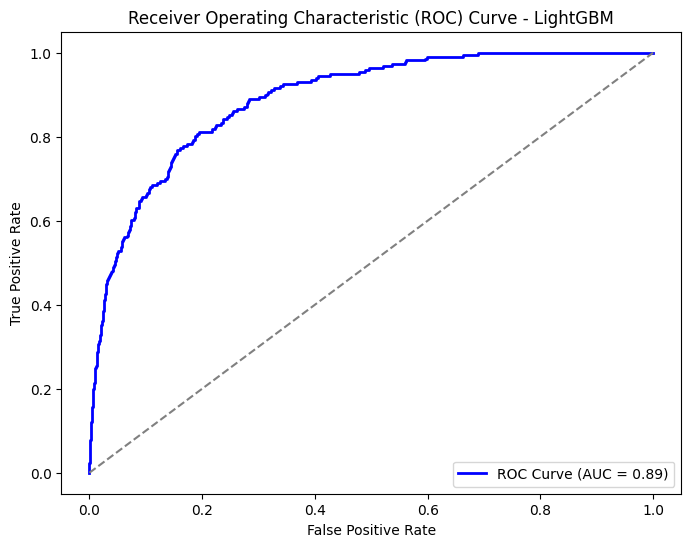

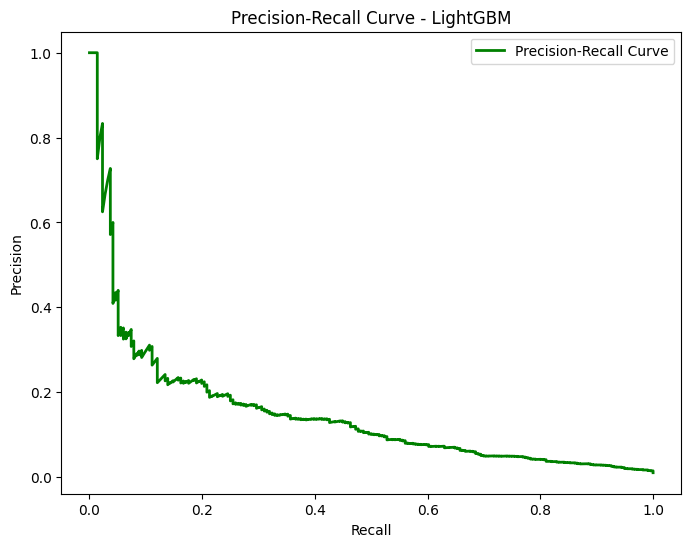

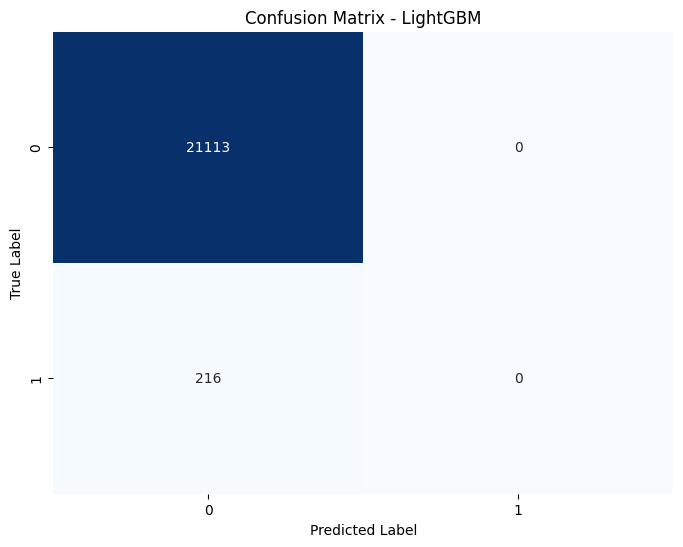

Model: XGBoost
Accuracy: 0.9900604810352103
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.58      0.07      0.12       216

    accuracy                           0.99     21329
   macro avg       0.78      0.53      0.56     21329
weighted avg       0.99      0.99      0.99     21329





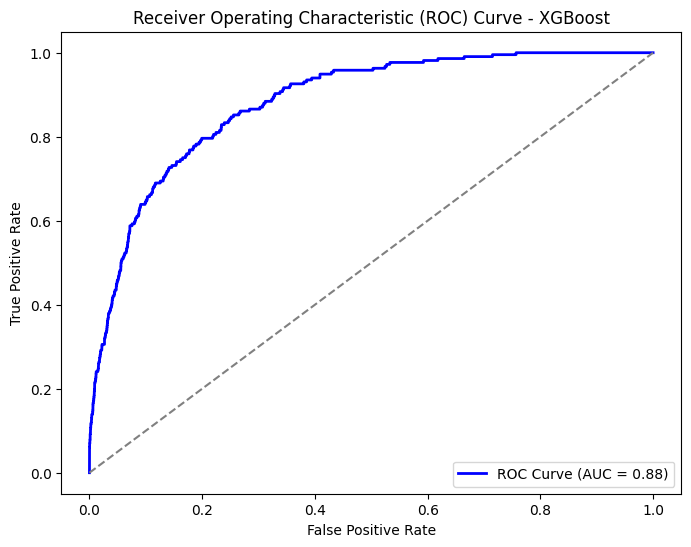

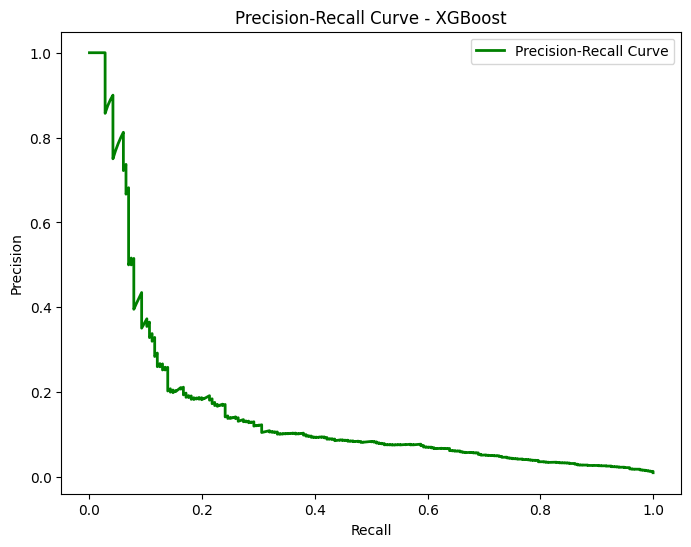

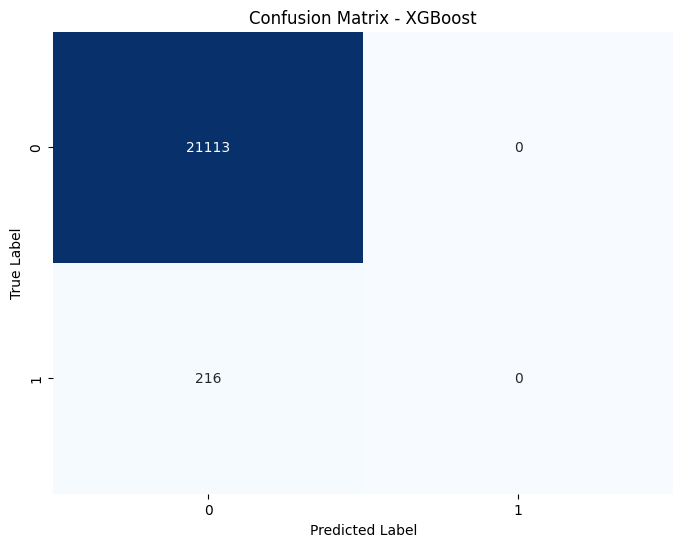

Model: Linear Discriminant Analysis
Accuracy: 0.9819494584837545
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     21113
         1.0       0.10      0.09      0.09       216

    accuracy                           0.98     21329
   macro avg       0.54      0.54      0.54     21329
weighted avg       0.98      0.98      0.98     21329





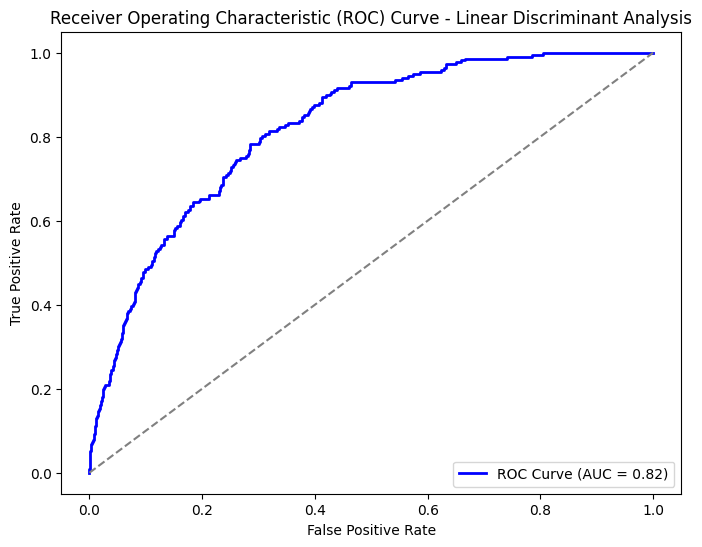

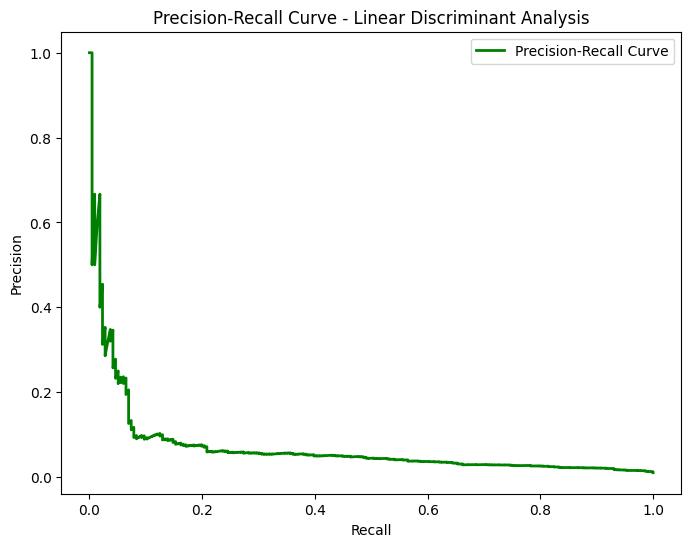

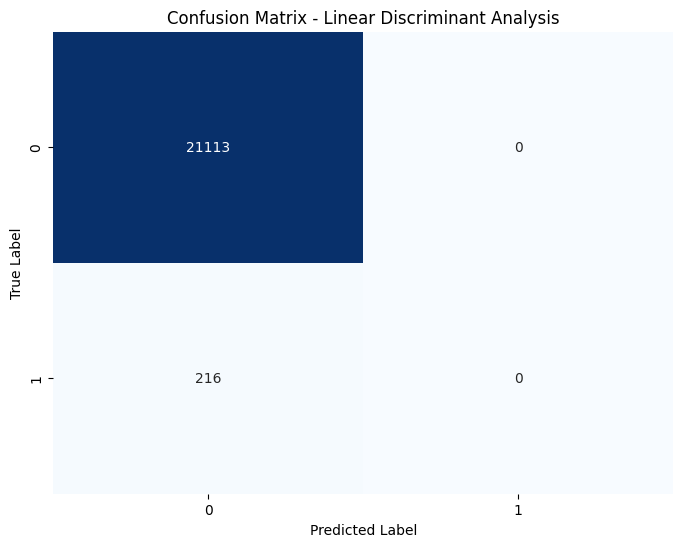

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Bagging": BaggingClassifier(),
    "LightGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier(),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis()
}

train_results_summary = {}

for name, model in models.items():
    print("Training", name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_score = roc_auc_score(y_test, y_pred_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

    optimal_cutoff = np.argmax(precision - recall)

    y_pred_binary = np.where(y_pred_prob >= optimal_cutoff, 1, 0)
    conf_matrix = confusion_matrix(y_test, y_pred_binary)

    train_results_summary[name] = {
        "Accuracy": accuracy,
        "Classification Report": report,
        "ROC Curve": (fpr, tpr, auc_score),
        "Precision-Recall Curve": (precision, recall, optimal_cutoff),
        "Confusion Matrix": conf_matrix
    }

print("\nTraining Results Summary:")
for name, result in train_results_summary.items():
    print(f"Model: {name}")
    print("Accuracy:", result["Accuracy"])
    print("Classification Report:\n", result["Classification Report"])
    print("\n")

    fpr, tpr, auc_score = result["ROC Curve"]
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {name}')
    plt.legend(loc='lower right')
    plt.show()

    precision, recall, optimal_cutoff = result["Precision-Recall Curve"]
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.legend(loc='upper right')
    plt.show()

    conf_matrix = result["Confusion Matrix"]
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

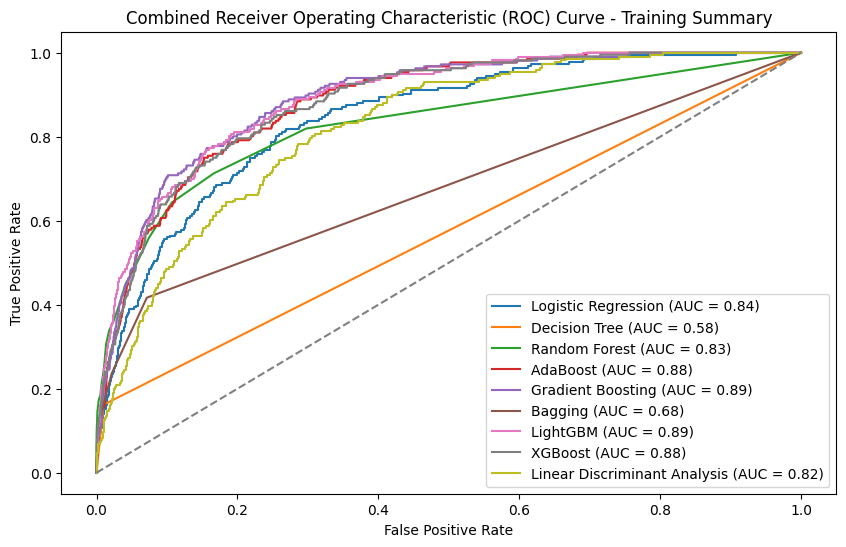

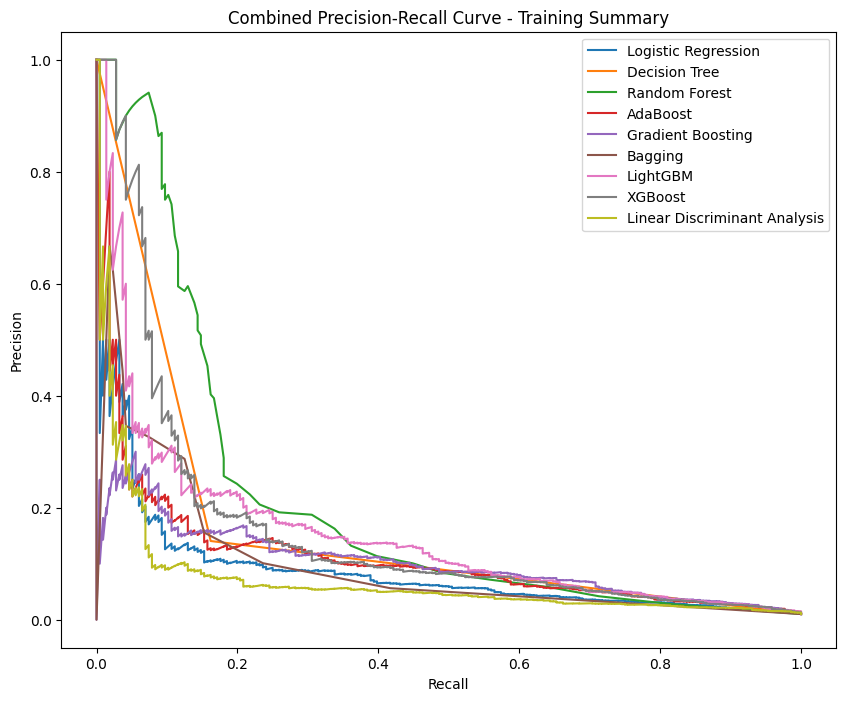

In [ ]:
plt.figure(figsize=(10, 6))
for name, result in train_results_summary.items():
    fpr, tpr, auc_score = result["ROC Curve"]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined Receiver Operating Characteristic (ROC) Curve - Training Summary')
plt.legend()
plt.show()

plt.figure(figsize=(10, 8))
for name, result in train_results_summary.items():
    precision, recall, _ = result["Precision-Recall Curve"]
    plt.plot(recall, precision, label=f'{name}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Combined Precision-Recall Curve - Training Summary')
plt.legend()
plt.show()


Test Results Summary for Model: Logistic Regression
Test Accuracy: 0.9899198274649538
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       1.00      0.00      0.01       216

    accuracy                           0.99     21329
   macro avg       0.99      0.50      0.50     21329
weighted avg       0.99      0.99      0.98     21329



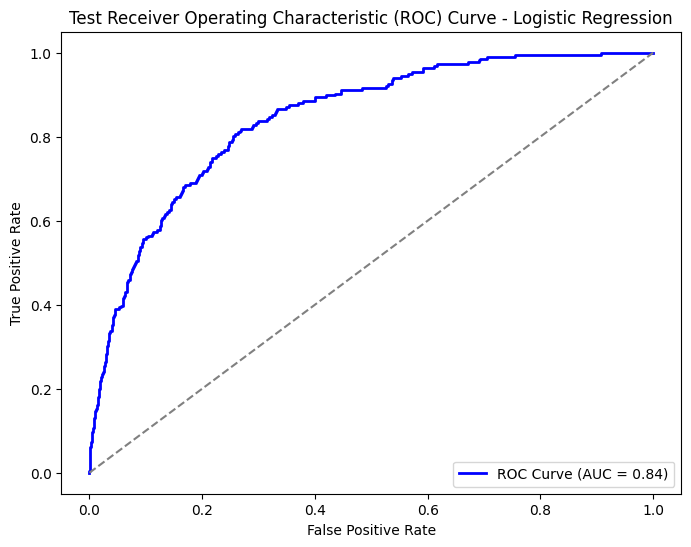

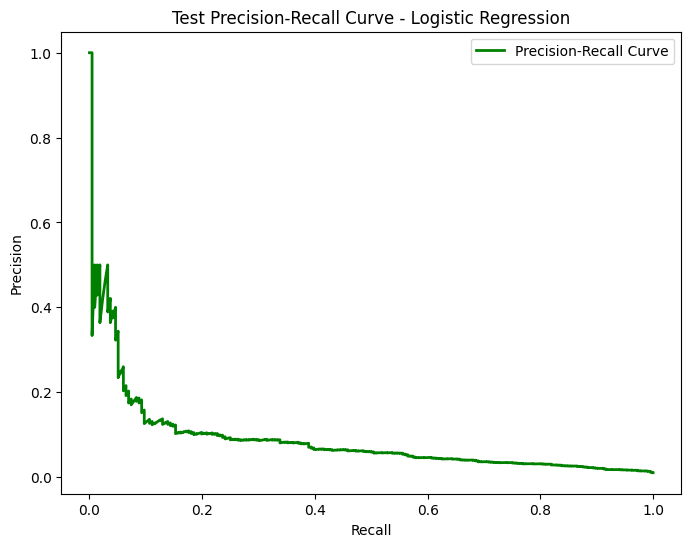

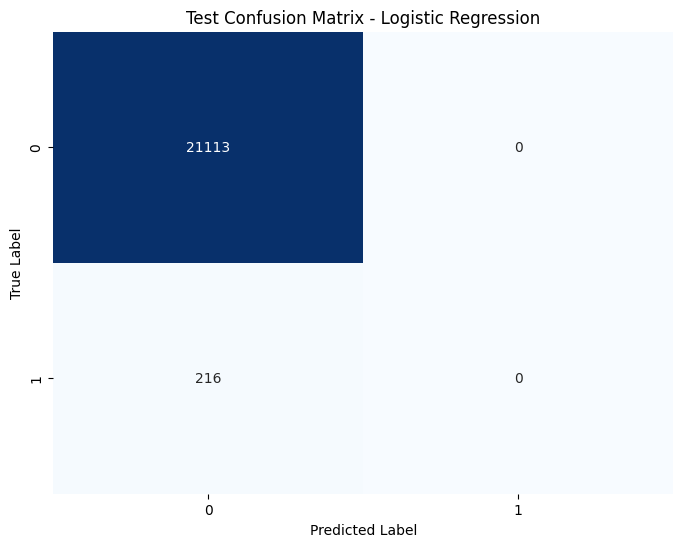


Test Results Summary for Model: Decision Tree
Test Accuracy: 0.9814806132495664
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     21113
         1.0       0.14      0.16      0.15       216

    accuracy                           0.98     21329
   macro avg       0.57      0.58      0.57     21329
weighted avg       0.98      0.98      0.98     21329



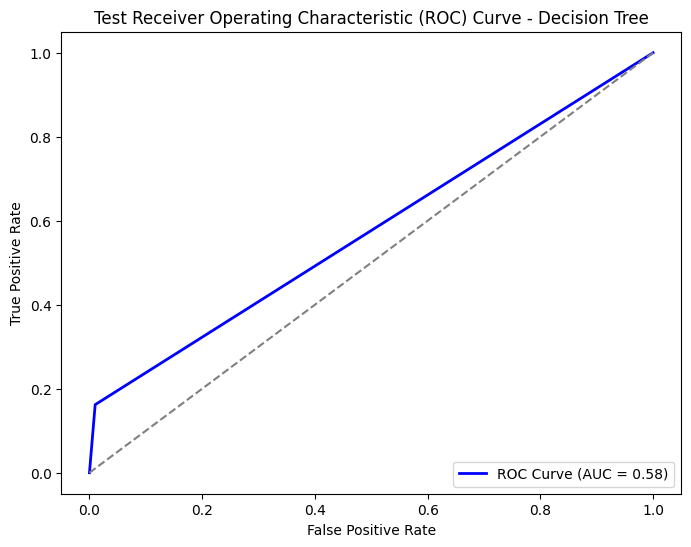

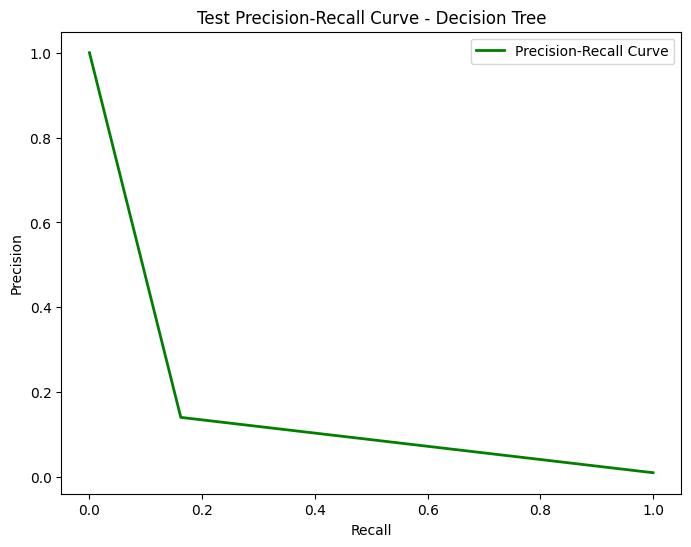

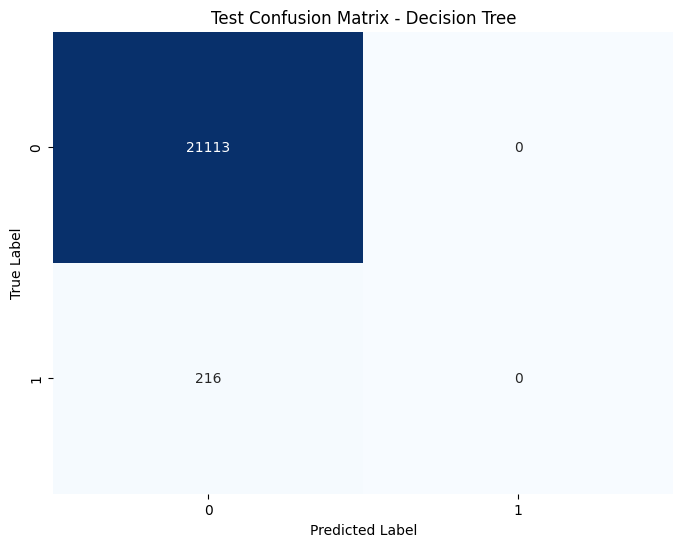


Test Results Summary for Model: Random Forest
Test Accuracy: 0.9904355572225608
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.93      0.06      0.11       216

    accuracy                           0.99     21329
   macro avg       0.96      0.53      0.55     21329
weighted avg       0.99      0.99      0.99     21329



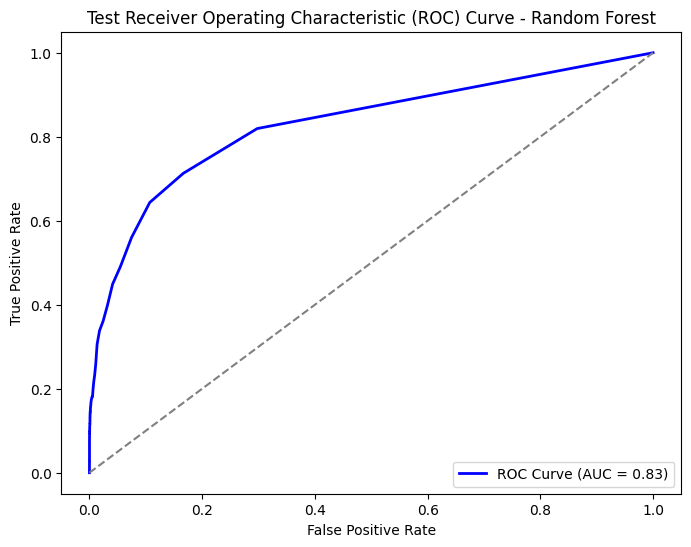

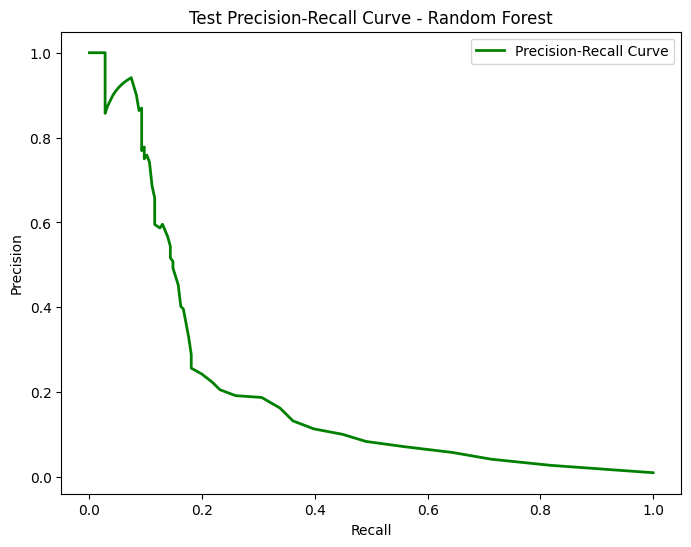

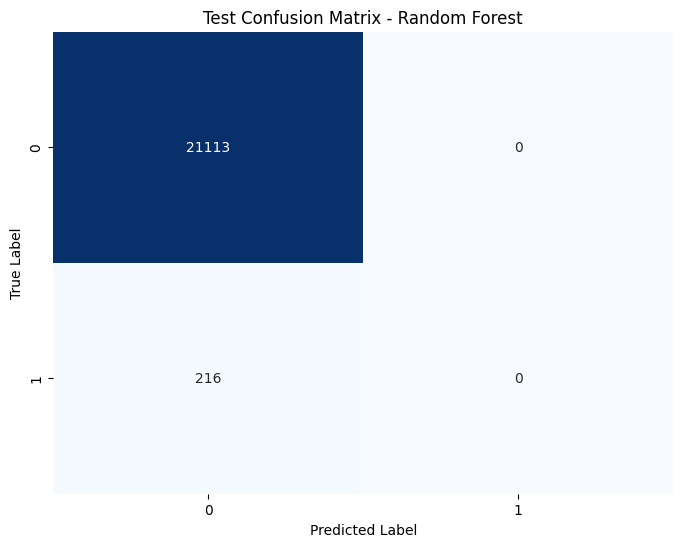


Test Results Summary for Model: AdaBoost
Test Accuracy: 0.9895447512776032
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.33      0.03      0.06       216

    accuracy                           0.99     21329
   macro avg       0.66      0.52      0.53     21329
weighted avg       0.98      0.99      0.99     21329



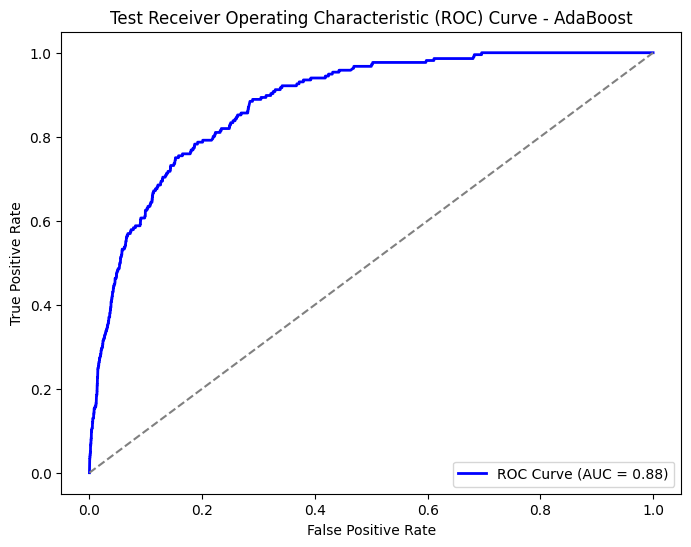

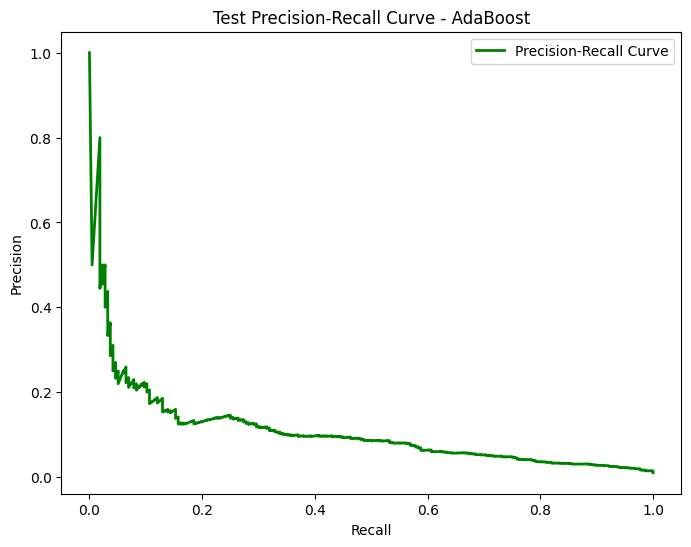

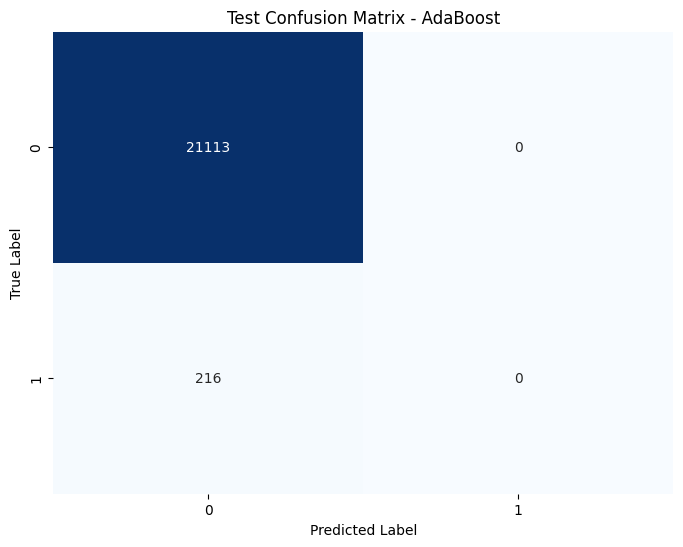


Test Results Summary for Model: Gradient Boosting
Test Accuracy: 0.9890759060434151
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.26      0.04      0.07       216

    accuracy                           0.99     21329
   macro avg       0.62      0.52      0.53     21329
weighted avg       0.98      0.99      0.99     21329



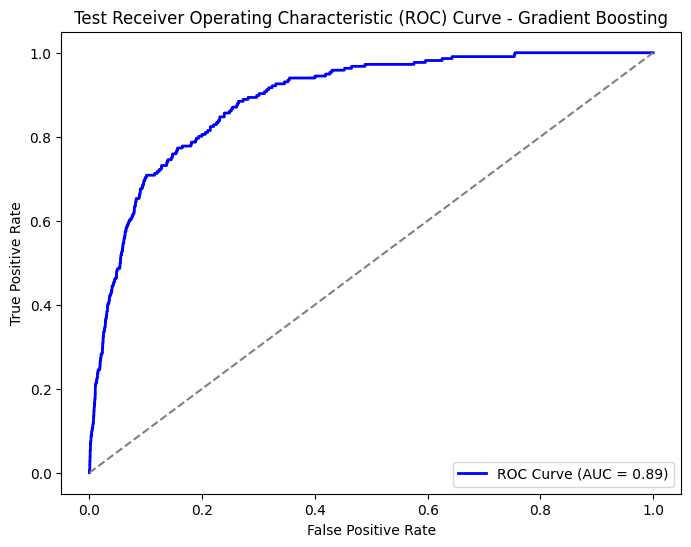

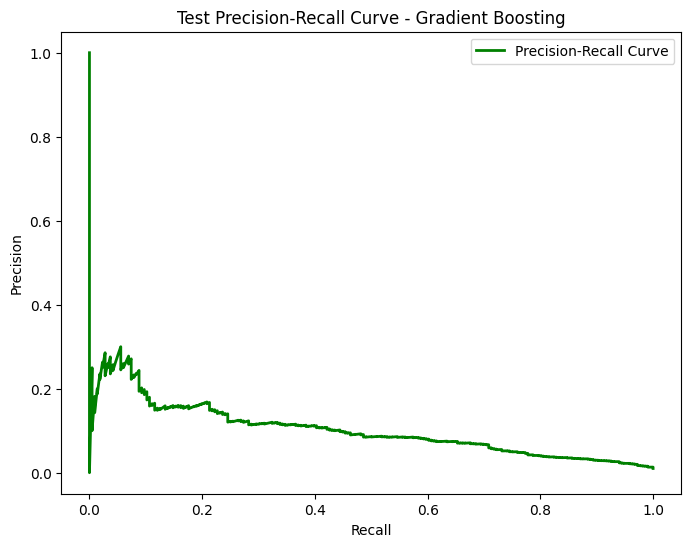

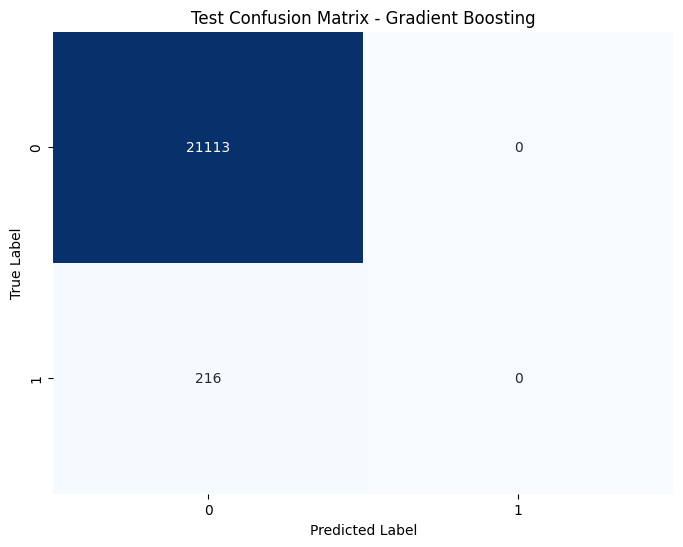


Test Results Summary for Model: Bagging
Test Accuracy: 0.9894978667541845
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.35      0.04      0.07       216

    accuracy                           0.99     21329
   macro avg       0.67      0.52      0.53     21329
weighted avg       0.98      0.99      0.99     21329



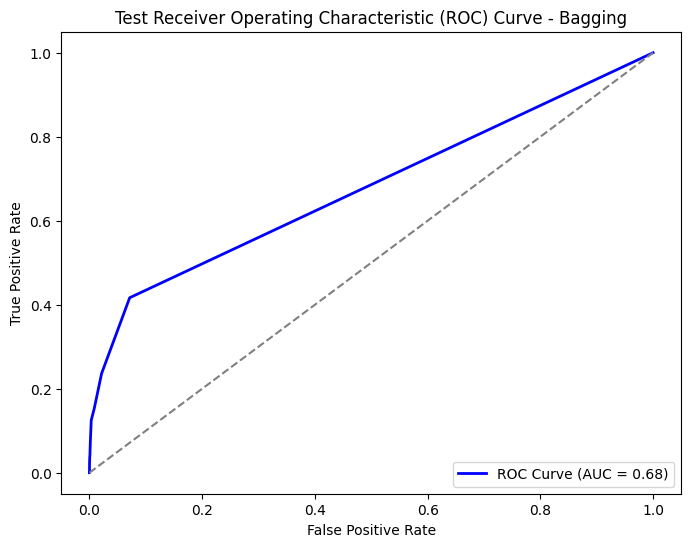

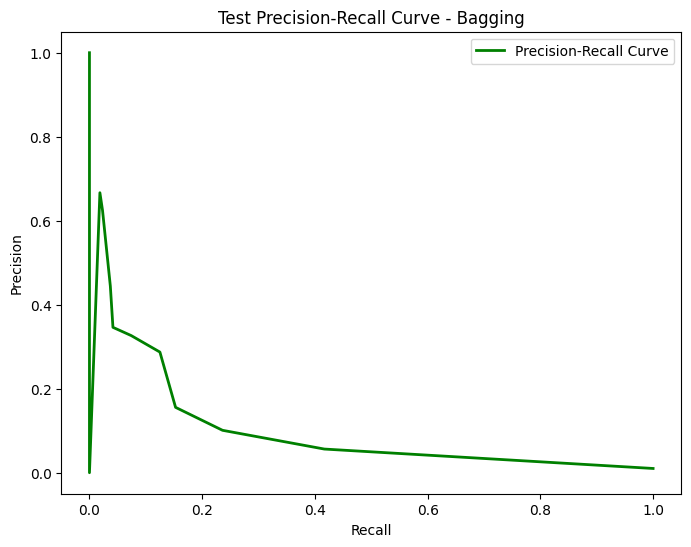

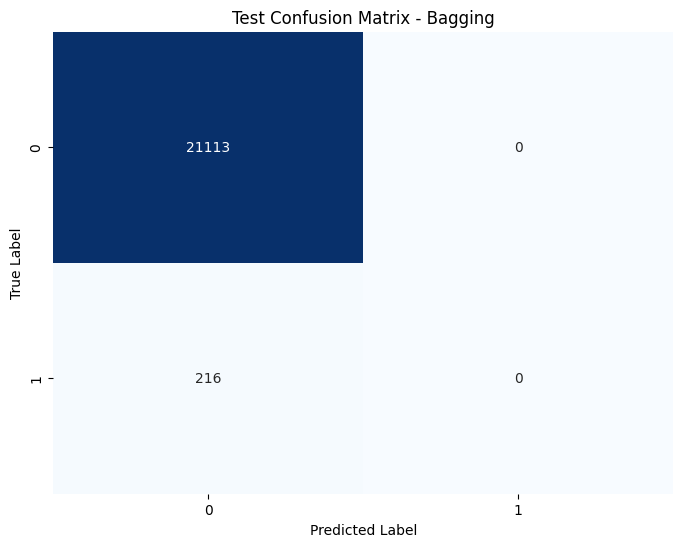


Test Results Summary for Model: LightGBM
Test Accuracy: 0.9890759060434151
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.33      0.07      0.12       216

    accuracy                           0.99     21329
   macro avg       0.66      0.54      0.56     21329
weighted avg       0.98      0.99      0.99     21329



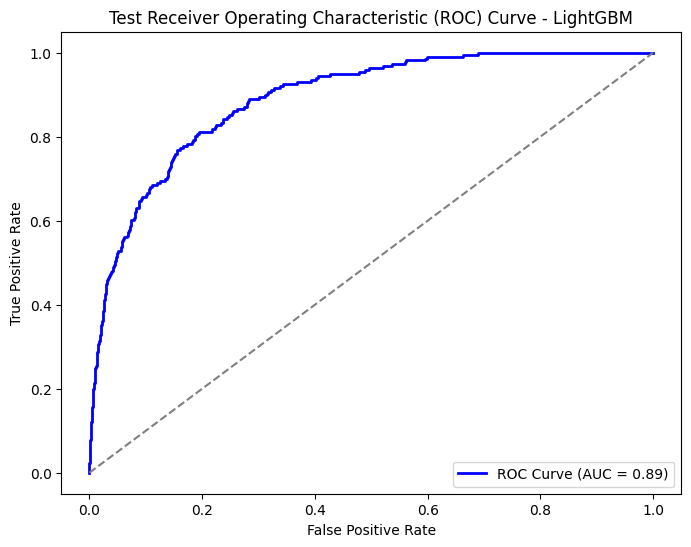

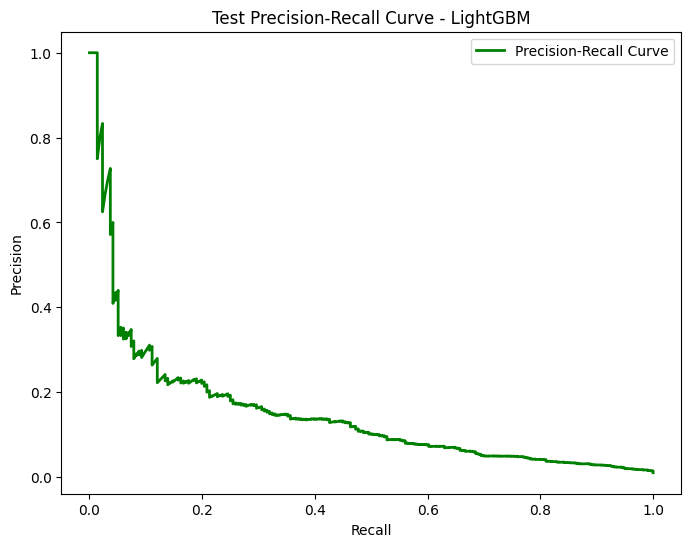

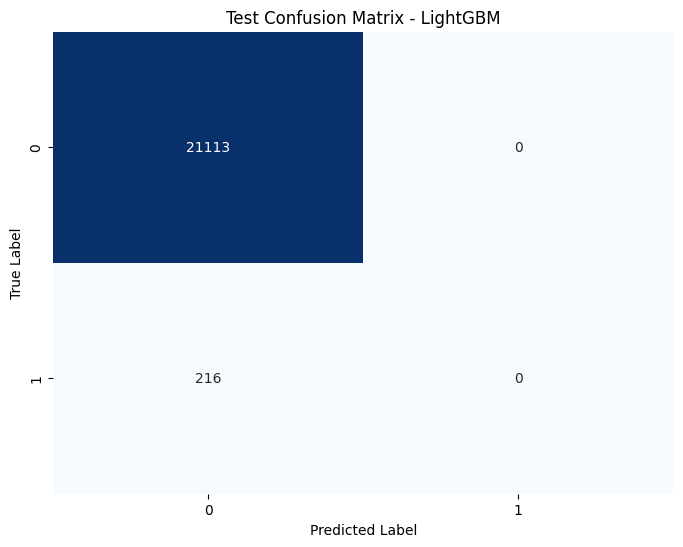


Test Results Summary for Model: XGBoost
Test Accuracy: 0.9900604810352103
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.58      0.07      0.12       216

    accuracy                           0.99     21329
   macro avg       0.78      0.53      0.56     21329
weighted avg       0.99      0.99      0.99     21329



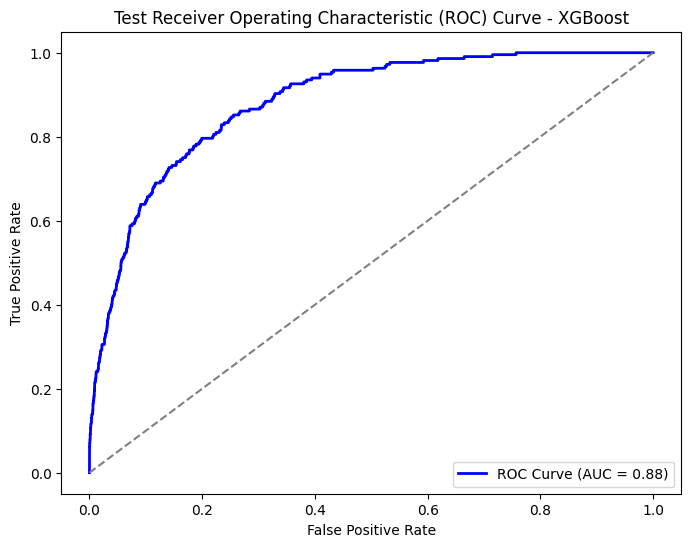

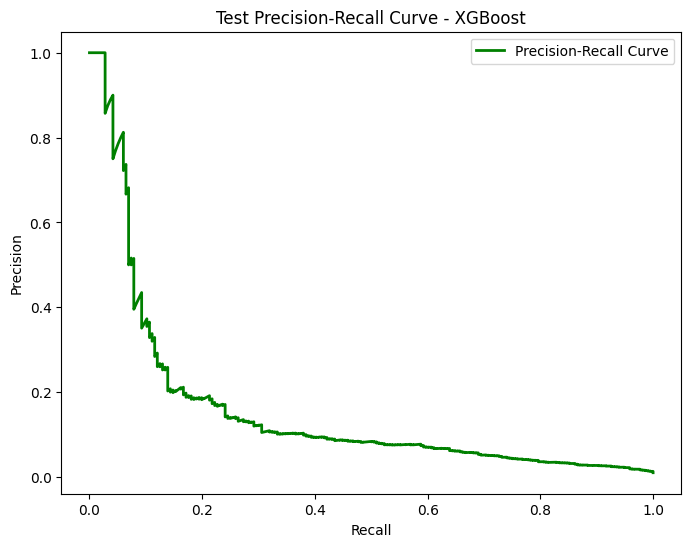

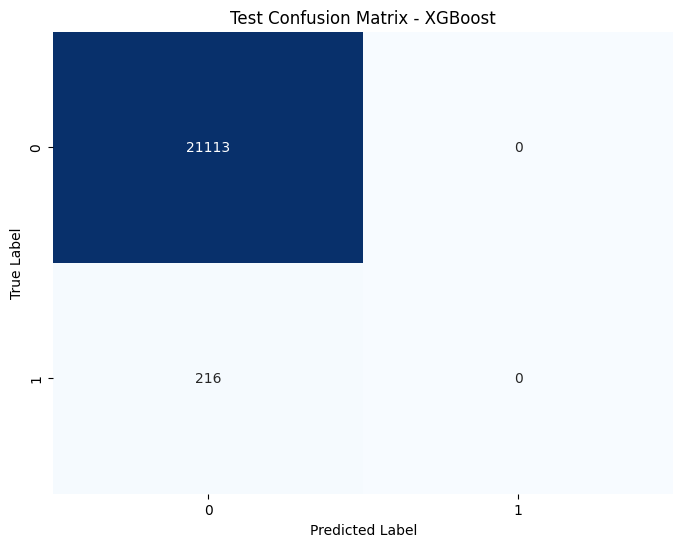


Test Results Summary for Model: Linear Discriminant Analysis
Test Accuracy: 0.9819494584837545
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     21113
         1.0       0.10      0.09      0.09       216

    accuracy                           0.98     21329
   macro avg       0.54      0.54      0.54     21329
weighted avg       0.98      0.98      0.98     21329



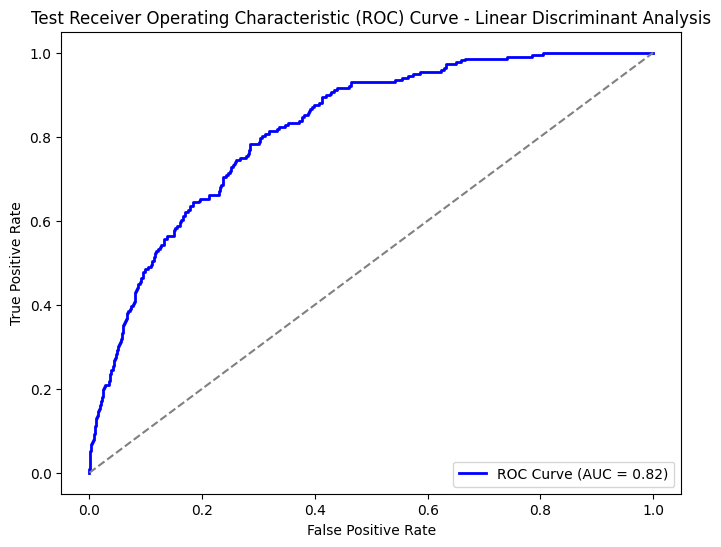

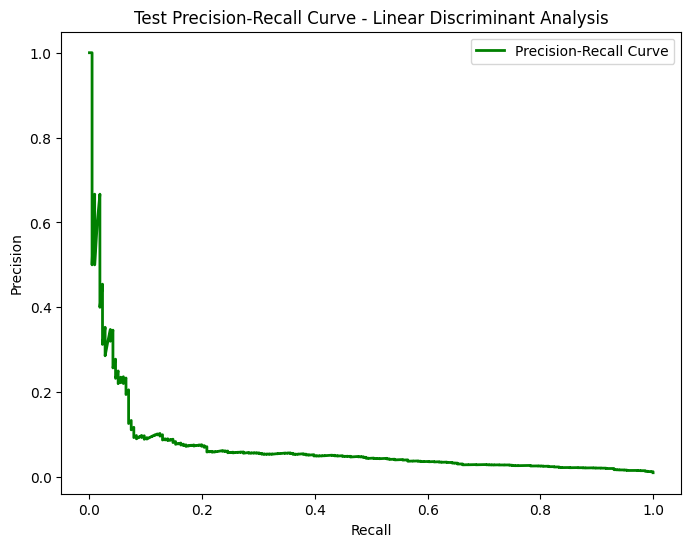

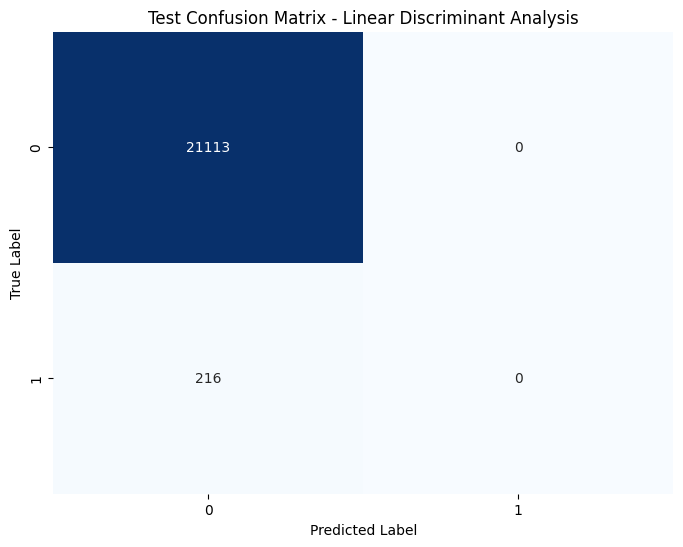

In [ ]:
test_results_summary = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)

    test_report = classification_report(y_test, y_pred)

    test_fpr, test_tpr, _ = roc_curve(y_test, y_pred_prob)
    test_auc_score = roc_auc_score(y_test, y_pred_prob)

    test_precision, test_recall, _ = precision_recall_curve(y_test, y_pred_prob)

    test_optimal_cutoff = np.argmax(test_precision - test_recall)

    y_pred_binary = np.where(y_pred_prob >= test_optimal_cutoff, 1, 0)
    test_conf_matrix = confusion_matrix(y_test, y_pred_binary)

    test_results_summary[name] = {
        "Test Accuracy": test_accuracy,
        "Test Classification Report": test_report,
        "Test ROC Curve": (test_fpr, test_tpr, test_auc_score),
        "Test Precision-Recall Curve": (test_precision, test_recall, test_optimal_cutoff),
        "Test Confusion Matrix": test_conf_matrix
    }

    print(f"\nTest Results Summary for Model: {name}")
    print("Test Accuracy:", test_accuracy)
    print("Test Classification Report:\n", test_report)

    plt.figure(figsize=(8, 6))
    plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % test_auc_score)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Test Receiver Operating Characteristic (ROC) Curve - {name}')
    plt.legend(loc='lower right')
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(test_recall, test_precision, color='green', lw=2, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Test Precision-Recall Curve - {name}')
    plt.legend(loc='upper right')
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Test Confusion Matrix - {name}')
    plt.show()

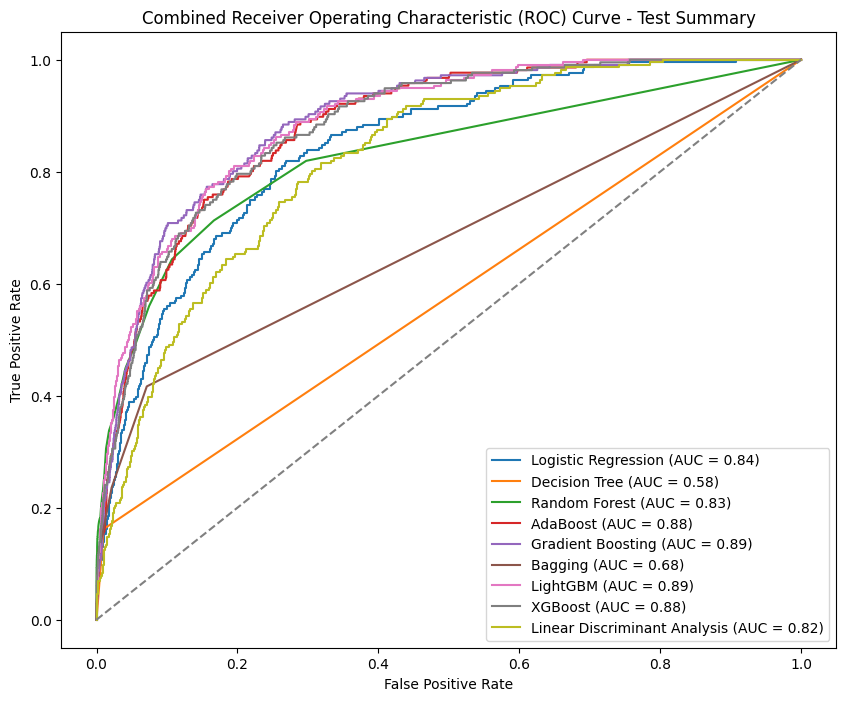

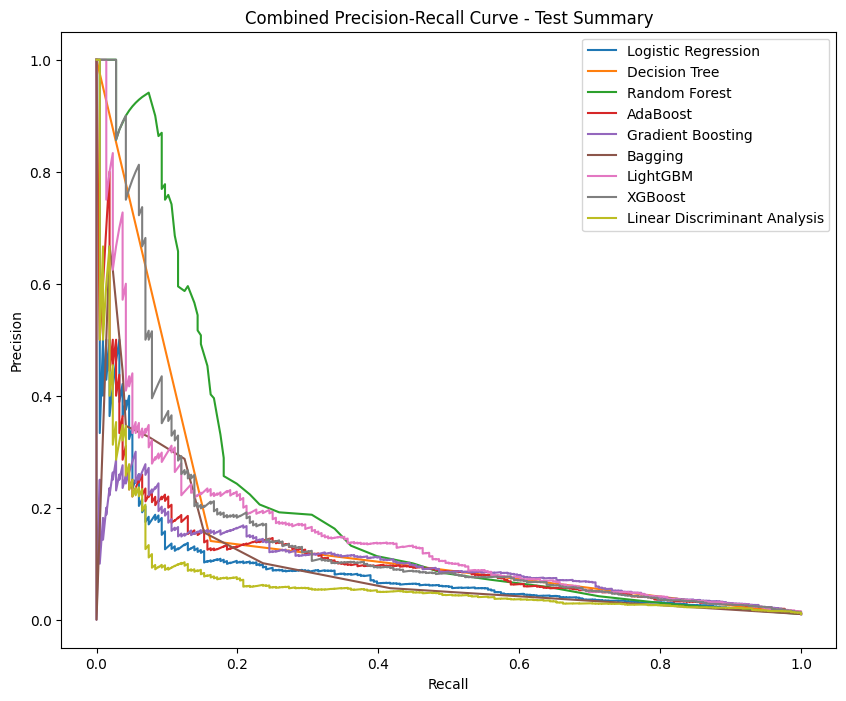

In [ ]:
plt.figure(figsize=(10, 8))
for name, result in test_results_summary.items():
    test_fpr, test_tpr, test_auc_score = result["Test ROC Curve"]
    plt.plot(test_fpr, test_tpr, label=f'{name} (AUC = {test_auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined Receiver Operating Characteristic (ROC) Curve - Test Summary')
plt.legend()
plt.show()

plt.figure(figsize=(10, 8))
for name, result in test_results_summary.items():
    test_precision, test_recall, _ = result["Test Precision-Recall Curve"]
    plt.plot(test_recall, test_precision, label=f'{name}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Combined Precision-Recall Curve - Test Summary')
plt.legend()
plt.show()

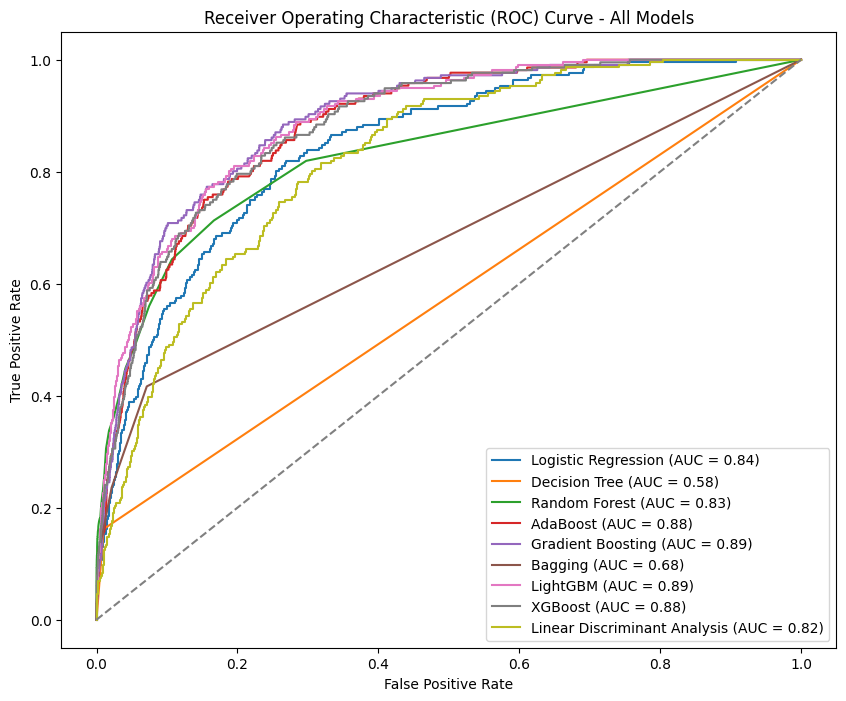

In [ ]:
plt.figure(figsize=(10, 8))

for name, result in test_results_summary.items():
    test_fpr, test_tpr, test_auc_score = result["Test ROC Curve"]
    plt.plot(test_fpr, test_tpr, label=f'{name} (AUC = {test_auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - All Models')
plt.legend(loc='lower right')
plt.show()


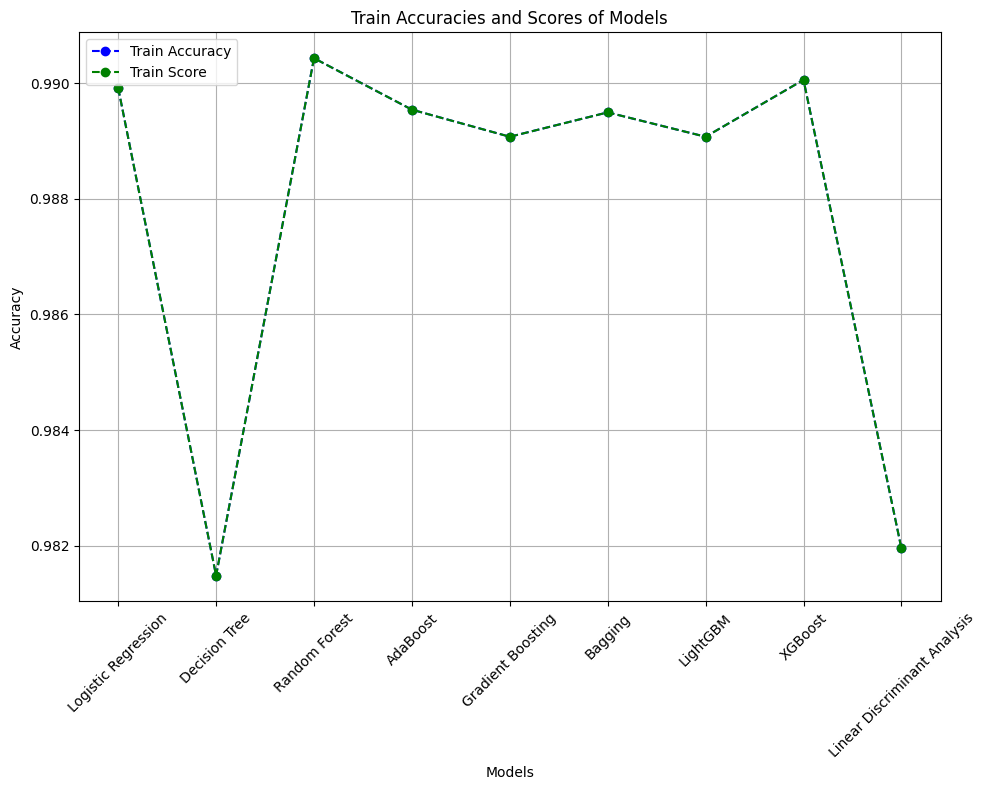

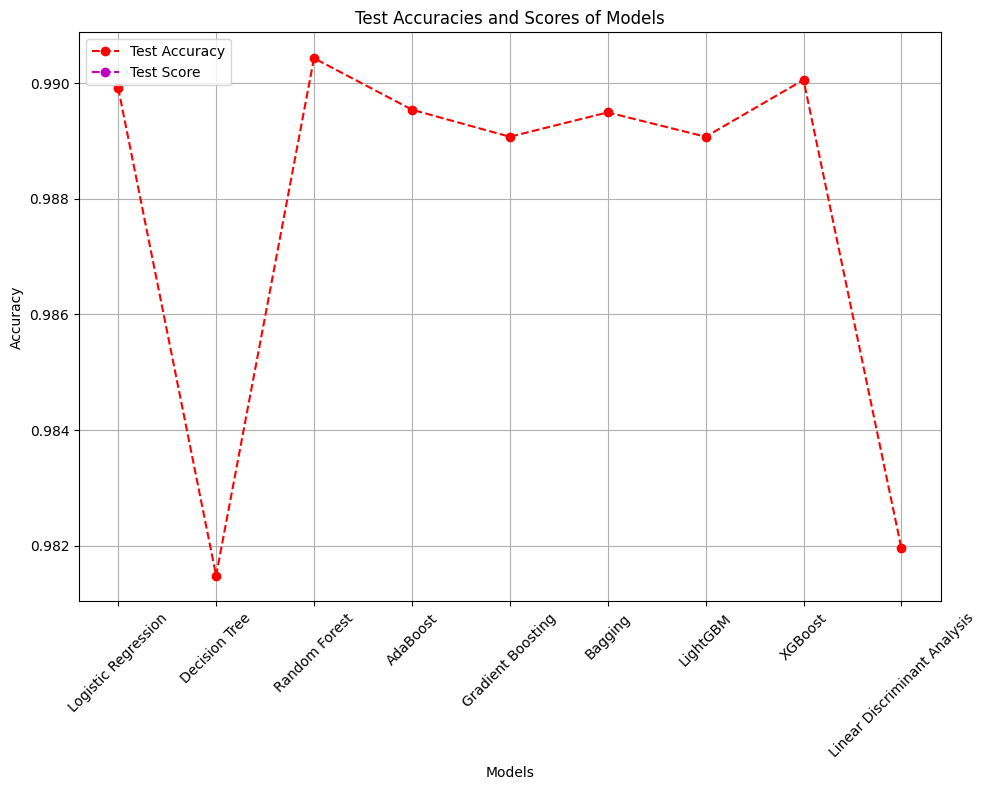

Best model based on train accuracy: Random Forest (Accuracy: 0.9904355572225608, Score: 0.9904355572225608)


KeyError: 'Random Forest'

In [ ]:
train_accuracies = {}
train_scores = {}
test_accuracies = {}
test_scores = {}

for name, result in train_results_summary.items():
    train_accuracies[name] = result["Accuracy"]
    train_scores[name] = result["Accuracy"]

for name, result in test_results_summary.items():
    test_accuracies[name] = result["Test Accuracy"]

plt.figure(figsize=(10, 8))
plt.plot(train_accuracies.keys(), train_accuracies.values(), marker='o', linestyle='--', color='b', label='Train Accuracy')
plt.plot(train_scores.keys(), train_scores.values(), marker='o', linestyle='--', color='g', label='Train Score')
plt.title('Train Accuracies and Scores of Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if test_accuracies:
    plt.figure(figsize=(10, 8))
    plt.plot(test_accuracies.keys(), test_accuracies.values(), marker='o', linestyle='--', color='r', label='Test Accuracy')
    plt.plot(test_scores.keys(), test_scores.values(), marker='o', linestyle='--', color='m', label='Test Score')
    plt.title('Test Accuracies and Scores of Models')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No test results found for any model.")

best_model_train = max(train_accuracies, key=train_accuracies.get)
print(f"Best model based on train accuracy: {best_model_train} (Accuracy: {train_accuracies[best_model_train]}, Score: {train_scores[best_model_train]})")

if test_accuracies and test_accuracies.get('Random Forest'):
    best_model_test = max(test_accuracies, key=test_accuracies.get)
    print(f"Best model based on test accuracy: {best_model_test} (Accuracy: {test_accuracies[best_model_test]}, Score: {test_scores[best_model_test]})")
else:
    print("No test results found for 'Random Forest' model.")



Test Results Summary for Model: Voting Classifier
Test Accuracy: 0.9903417881757232
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.75      0.07      0.13       216

    accuracy                           0.99     21329
   macro avg       0.87      0.53      0.56     21329
weighted avg       0.99      0.99      0.99     21329



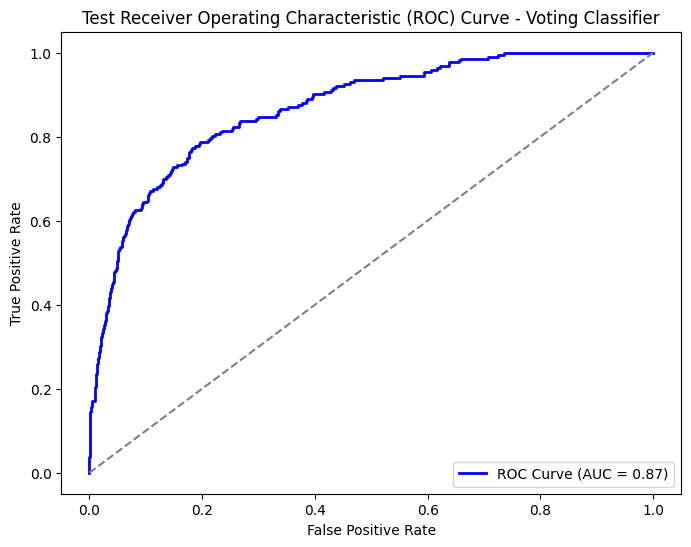

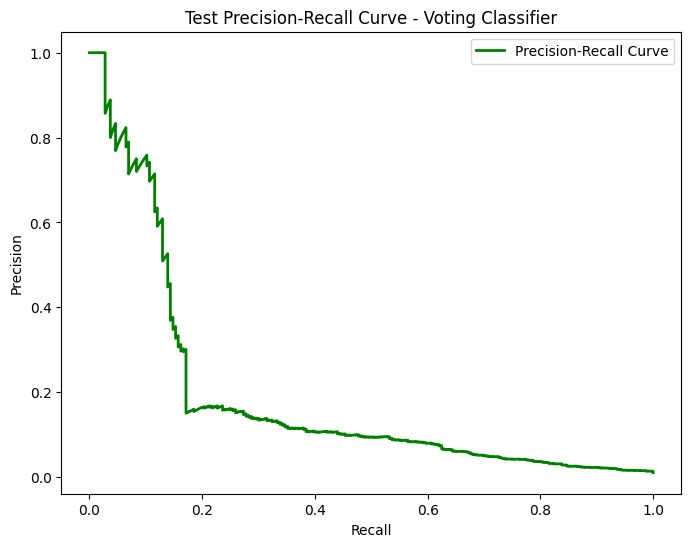

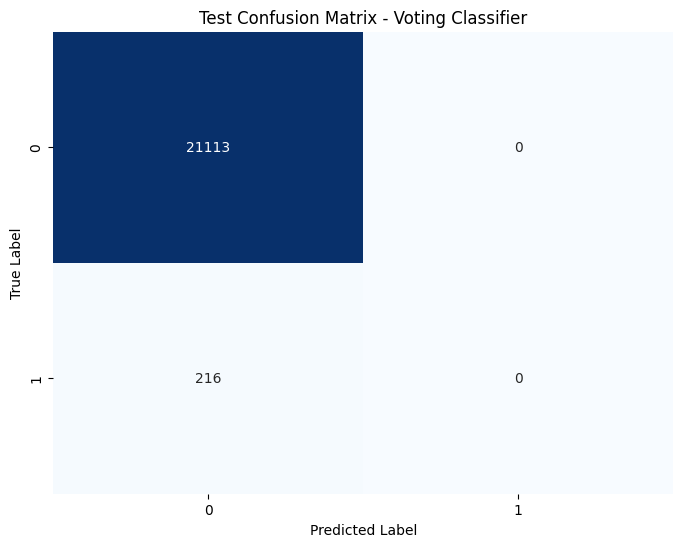


Test Results Summary for Model: AdaBoost Classifier
Test Accuracy: 0.989872942941535
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.00      0.00      0.00       216

    accuracy                           0.99     21329
   macro avg       0.49      0.50      0.50     21329
weighted avg       0.98      0.99      0.98     21329



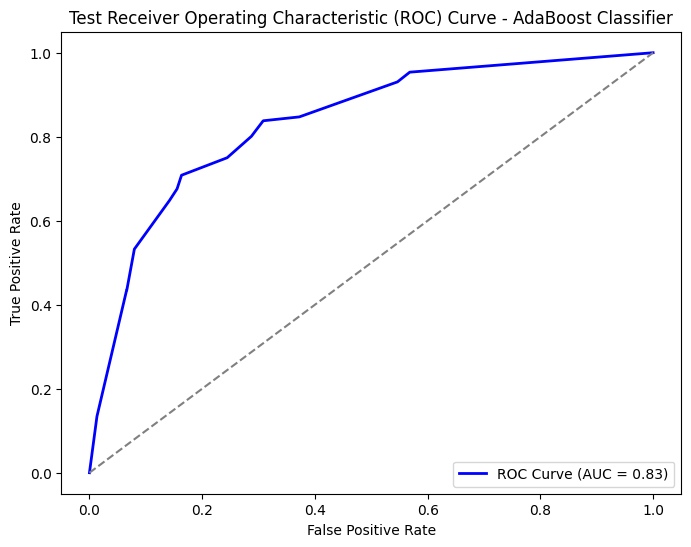

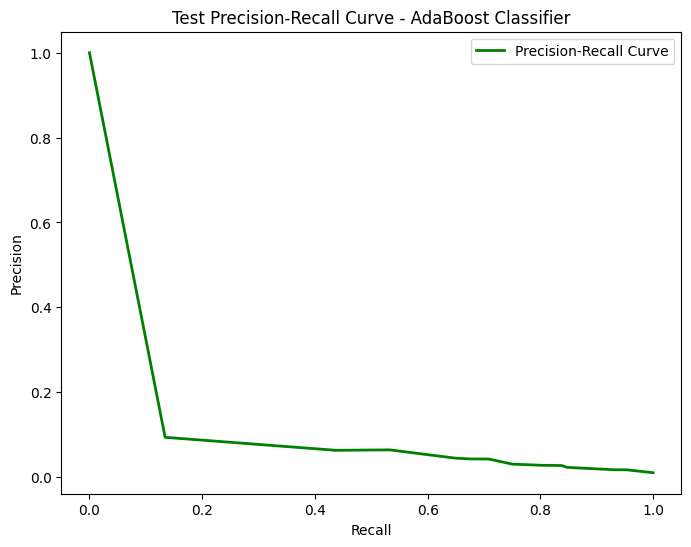

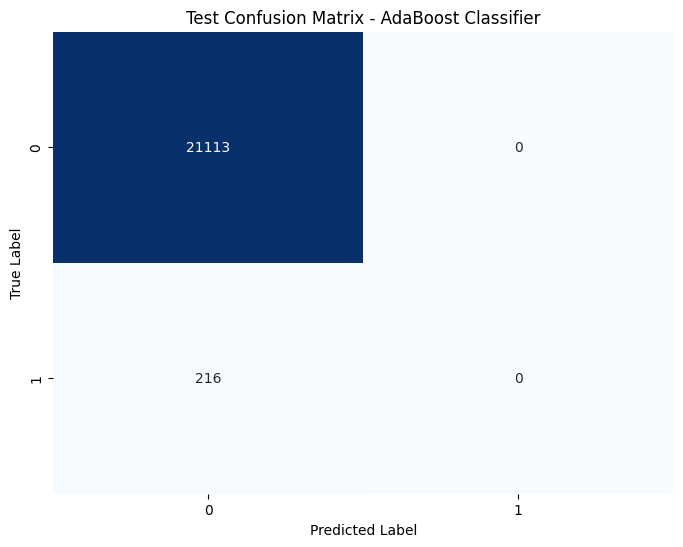


Test Results Summary for Model: Gradient Boosting Classifier
Test Accuracy: 0.9899198274649538
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       1.00      0.00      0.01       216

    accuracy                           0.99     21329
   macro avg       0.99      0.50      0.50     21329
weighted avg       0.99      0.99      0.98     21329



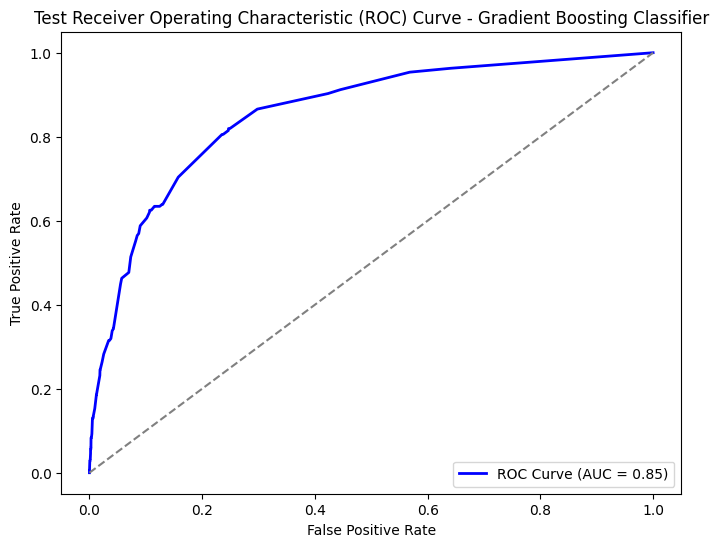

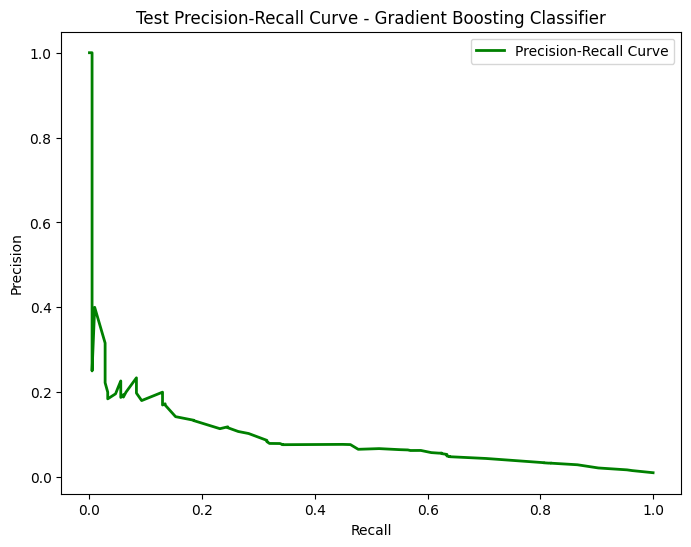

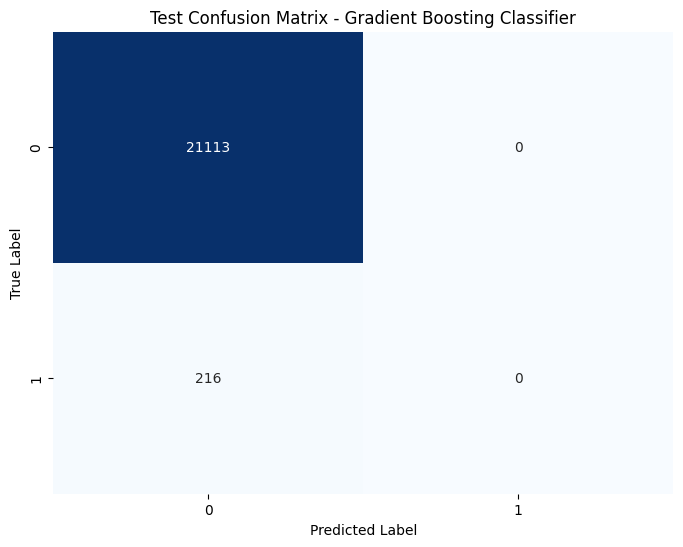


Test Results Summary:
Model: Voting Classifier
Test Accuracy: 0.9903417881757232
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.75      0.07      0.13       216

    accuracy                           0.99     21329
   macro avg       0.87      0.53      0.56     21329
weighted avg       0.99      0.99      0.99     21329



Model: AdaBoost Classifier
Test Accuracy: 0.989872942941535
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     21113
         1.0       0.00      0.00      0.00       216

    accuracy                           0.99     21329
   macro avg       0.49      0.50      0.50     21329
weighted avg       0.98      0.99      0.98     21329



Model: Gradient Boosting Classifier
Test Accuracy: 0.9899198274649538
Test Classification Report:
               precision    recall  f1-score

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report

base_classifiers = [
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('Logistic Regression', LogisticRegression())
]
voting_classifier = VotingClassifier(estimators=base_classifiers, voting='soft')

# Define hyperparameters grid for grid search
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0]
}
adaboost_grid_search = GridSearchCV(AdaBoostClassifier(), param_grid=param_grid, cv=5)
adaboost_grid_search.fit(X_train, y_train)
best_adaboost_model = adaboost_grid_search.best_estimator_

gradient_boost_grid_search = GridSearchCV(GradientBoostingClassifier(), param_grid=param_grid, cv=5)
gradient_boost_grid_search.fit(X_train, y_train)
best_gradient_boost_model = gradient_boost_grid_search.best_estimator_

# Train Voting Classifier
voting_classifier.fit(X_train, y_train)

models = {
    "Voting Classifier": voting_classifier,
    "AdaBoost Classifier": best_adaboost_model,
    "Gradient Boosting Classifier": best_gradient_boost_model
}

test_results_summary = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for positive class

    test_accuracy = accuracy_score(y_test, y_pred)

    test_report = classification_report(y_test, y_pred)

    test_fpr, test_tpr, _ = roc_curve(y_test, y_pred_prob)
    test_auc_score = roc_auc_score(y_test, y_pred_prob)

    test_precision, test_recall, _ = precision_recall_curve(y_test, y_pred_prob)

    test_optimal_cutoff = np.argmax(test_precision - test_recall)

    y_pred_binary = np.where(y_pred_prob >= test_optimal_cutoff, 1, 0)
    test_conf_matrix = confusion_matrix(y_test, y_pred_binary)

    test_results_summary[name] = {
        "Test Accuracy": test_accuracy,
        "Test Classification Report": test_report,
        "Test ROC Curve": (test_fpr, test_tpr, test_auc_score),
        "Test Precision-Recall Curve": (test_precision, test_recall, test_optimal_cutoff),
        "Test Confusion Matrix": test_conf_matrix
    }

    print(f"\nTest Results Summary for Model: {name}")
    print("Test Accuracy:", test_accuracy)
    print("Test Classification Report:\n", test_report)

    plt.figure(figsize=(8, 6))
    plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % test_auc_score)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Test Receiver Operating Characteristic (ROC) Curve - {name}')
    plt.legend(loc='lower right')
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(test_recall, test_precision, color='green', lw=2, label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Test Precision-Recall Curve - {name}')
    plt.legend(loc='upper right')
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Test Confusion Matrix - {name}')
    plt.show()

print("\nTest Results Summary:")
for name, result in test_results_summary.items():
    print(f"Model: {name}")
    print("Test Accuracy:", result["Test Accuracy"])
    print("Test Classification Report:\n", result["Test Classification Report"])
    print("\n")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
}

rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5)
rf_grid_search.fit(X_train, y_train)

best_rf_model = rf_grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf)

print("Random Forest Model Tuning Results:")
print("Best Hyperparameters:", rf_grid_search.best_params_)
print("Best Model Accuracy:", rf_accuracy)
print("Classification Report:\n", rf_report)

Random Forest Model Tuning Results:
Best Hyperparameters: {'max_depth': None, 'n_estimators': 50}
Best Model Accuracy: 0.9902949036523043
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     21113
         1.0       0.85      0.05      0.10       216

    accuracy                           0.99     21329
   macro avg       0.92      0.53      0.55     21329
weighted avg       0.99      0.99      0.99     21329

